In [1]:
print("Mumbai Climate - New ML Model Data Collection Notebook")

Mumbai Climate - New ML Model Data Collection Notebook


In [2]:
# STEP 1A — MUMBAI HOURLY HISTORICAL WEATHER DATA

import pandas as pd
import numpy as np
import requests
import os

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# MUMBAI LOCATION

MUMBAI_LAT = 19.0760
MUMBAI_LON = 72.8777

TIMEZONE = "Asia/Kolkata"

print("Mumbai location configured!")
print("Latitude :", MUMBAI_LAT)
print("Longitude:", MUMBAI_LON)
print("Timezone :", TIMEZONE)

Mumbai location configured!
Latitude : 19.076
Longitude: 72.8777
Timezone : Asia/Kolkata


In [4]:
# HISTORICAL DATA PERIOD

START_DATE = "2022-01-01"
END_DATE = "2025-12-31"

print("Historical data period configured!")
print("Start date:", START_DATE)
print("End date  :", END_DATE)

Historical data period configured!
Start date: 2022-01-01
End date  : 2025-12-31


In [5]:
# HOURLY WEATHER VARIABLES

HOURLY_VARIABLES = [
    "temperature_2m",
    "relative_humidity_2m",
    "dew_point_2m",
    "apparent_temperature",
    "precipitation",
    "rain",
    "weather_code",
    "pressure_msl",
    "surface_pressure",
    "cloud_cover",
    "cloud_cover_low",
    "cloud_cover_mid",
    "cloud_cover_high",
    "wind_speed_10m",
    "wind_direction_10m",
    "wind_gusts_10m",
    "vapour_pressure_deficit",
    "visibility",
    "shortwave_radiation",
    "direct_radiation",
    "diffuse_radiation",
    "sunshine_duration",
    "wet_bulb_temperature_2m",
    "boundary_layer_height",
    "cape"
]

print("Hourly weather variables configured!")
print("Number of variables:", len(HOURLY_VARIABLES))
print("\nVariables:")
for variable in HOURLY_VARIABLES:
    print("-", variable)

Hourly weather variables configured!
Number of variables: 25

Variables:
- temperature_2m
- relative_humidity_2m
- dew_point_2m
- apparent_temperature
- precipitation
- rain
- weather_code
- pressure_msl
- surface_pressure
- cloud_cover
- cloud_cover_low
- cloud_cover_mid
- cloud_cover_high
- wind_speed_10m
- wind_direction_10m
- wind_gusts_10m
- vapour_pressure_deficit
- visibility
- shortwave_radiation
- direct_radiation
- diffuse_radiation
- sunshine_duration
- wet_bulb_temperature_2m
- boundary_layer_height
- cape


In [6]:
# OPEN-METEO HISTORICAL WEATHER API CONFIGURATION

BASE_URL = "https://archive-api.open-meteo.com/v1/archive"

params = {
    "latitude": MUMBAI_LAT,
    "longitude": MUMBAI_LON,
    "start_date": START_DATE,
    "end_date": END_DATE,
    "hourly": ",".join(HOURLY_VARIABLES),
    "timezone": TIMEZONE,
    "temperature_unit": "celsius",
    "wind_speed_unit": "kmh",
    "precipitation_unit": "mm"
}

print("API configuration created successfully!")
print("API:", BASE_URL)
print("Location:", MUMBAI_LAT, MUMBAI_LON)
print("Period:", START_DATE, "to", END_DATE)
print("Hourly variables:", len(HOURLY_VARIABLES))

API configuration created successfully!
API: https://archive-api.open-meteo.com/v1/archive
Location: 19.076 72.8777
Period: 2022-01-01 to 2025-12-31
Hourly variables: 25


In [7]:
# DOWNLOAD MUMBAI HOURLY HISTORICAL WEATHER DATA

print("Downloading Mumbai historical weather data...")
print("Please wait...")

response = requests.get(
    BASE_URL,
    params=params,
    timeout=120
)

print("\nHTTP Status:", response.status_code)

response.raise_for_status()

weather_json = response.json()

print("Historical weather data downloaded successfully!")

Please wait...

HTTP Status: 200
Historical weather data downloaded successfully!


In [8]:
# CELL 7 — CONVERT API RESPONSE TO DATAFRAME

hourly_data = weather_json["hourly"]

weather_hourly_df = pd.DataFrame(hourly_data)

# Convert timestamp to datetime
weather_hourly_df["time"] = pd.to_datetime(
    weather_hourly_df["time"]
)

print("Mumbai hourly dataset created successfully!")

print("\nDataset shape:")
print(weather_hourly_df.shape)

print("\nNumber of columns:")
print(len(weather_hourly_df.columns))

print("\nColumns:")
print(weather_hourly_df.columns.tolist())

print("\nFirst 5 rows:")
display(weather_hourly_df.head())

Mumbai hourly dataset created successfully!

Dataset shape:
(35064, 26)

Number of columns:
26

Columns:
['time', 'temperature_2m', 'relative_humidity_2m', 'dew_point_2m', 'apparent_temperature', 'precipitation', 'rain', 'weather_code', 'pressure_msl', 'surface_pressure', 'cloud_cover', 'cloud_cover_low', 'cloud_cover_mid', 'cloud_cover_high', 'wind_speed_10m', 'wind_direction_10m', 'wind_gusts_10m', 'vapour_pressure_deficit', 'visibility', 'shortwave_radiation', 'direct_radiation', 'diffuse_radiation', 'sunshine_duration', 'wet_bulb_temperature_2m', 'boundary_layer_height', 'cape']

First 5 rows:


,time,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,precipitation,rain,weather_code,pressure_msl,surface_pressure,...,wind_gusts_10m,vapour_pressure_deficit,visibility,shortwave_radiation,direct_radiation,diffuse_radiation,sunshine_duration,wet_bulb_temperature_2m,boundary_layer_height,cape
0,2022-01-01 00:00:00,22.5,74,17.5,24.1,0.0,0.0,1,1016.1,1015.4,...,15.1,0.72,None,0.0,0.0,0.0,0.0,19.0,120.0,None
1,2022-01-01 01:00:00,21.6,78,17.6,23.2,0.0,0.0,1,1015.9,1015.2,...,12.2,0.56,None,0.0,0.0,0.0,0.0,18.8,100.0,None
2,2022-01-01 02:00:00,21.4,77,17.1,22.4,0.0,0.0,1,1015.3,1014.6,...,17.3,0.60,None,0.0,0.0,0.0,0.0,18.4,90.0,None
3,2022-01-01 03:00:00,21.3,73,16.2,21.8,0.0,0.0,1,1015.1,1014.4,...,18.4,0.68,None,0.0,0.0,0.0,0.0,17.8,90.0,None
4,2022-01-01 04:00:00,20.8,73,15.7,21.3,0.0,0.0,0,1015.0,1014.3,...,18.0,0.67,None,0.0,0.0,0.0,0.0,17.3,95.0,None


In [9]:
# CELL 8 — VERIFY DATE AND TIME RANGE

print("Earliest timestamp:")
print(weather_hourly_df["time"].min())

print("\nLatest timestamp:")
print(weather_hourly_df["time"].max())

print("\nTotal hourly records:")
print(len(weather_hourly_df))

print("\nUnique dates:")
print(weather_hourly_df["time"].dt.date.nunique())

print("\nRecords per year:")
print(
    weather_hourly_df["time"]
    .dt.year
    .value_counts()
    .sort_index()
)

Earliest timestamp:
2022-01-01 00:00:00

Latest timestamp:
2025-12-31 23:00:00

Total hourly records:
35064

Unique dates:
1461

Records per year:
time
2022    8760
2023    8760
2024    8784
2025    8760
Name: count, dtype: int64


In [10]:
# CELL 9 — MISSING VALUE ANALYSIS

missing_count = weather_hourly_df.isnull().sum()

missing_percentage = (
    missing_count / len(weather_hourly_df) * 100
)

missing_report = pd.DataFrame({
    "Missing_Count": missing_count,
    "Missing_Percentage": missing_percentage
})

# Show only columns that contain missing values
missing_report = missing_report[
    missing_report["Missing_Count"] > 0
].sort_values(
    "Missing_Count",
    ascending=False
)

print("Missing-value analysis:")
display(missing_report)

print("\nTotal columns with missing values:",
      len(missing_report))

Missing-value analysis:


,Missing_Count,Missing_Percentage
visibility,35064,100.000000
cape,35064,100.000000
boundary_layer_height,4368,12.457221



Total columns with missing values: 3


In [11]:

# CELL 10 — ANALYZE BOUNDARY LAYER HEIGHT

blh_missing = weather_hourly_df[
    weather_hourly_df["boundary_layer_height"].isna()
].copy()

print("Missing boundary-layer records:",
      len(blh_missing))

print("\nFirst missing timestamps:")
display(
    blh_missing[["time"]].head(20)
)

print("\nLast missing timestamps:")
display(
    blh_missing[["time"]].tail(20)
)

print("\nMissing records by year:")
print(
    blh_missing["time"]
    .dt.year
    .value_counts()
    .sort_index()
)

print("\nMissing records by month:")
print(
    blh_missing["time"]
    .dt.month
    .value_counts()
    .sort_index()
)

Missing boundary-layer records: 4368

First missing timestamps:


,time
17525,2024-01-01 05:00:00
17526,2024-01-01 06:00:00
17527,2024-01-01 07:00:00
17528,2024-01-01 08:00:00
17529,2024-01-01 09:00:00
17530,2024-01-01 10:00:00
17531,2024-01-01 11:00:00
17532,2024-01-01 12:00:00
17533,2024-01-01 13:00:00
17534,2024-01-01 14:00:00



Last missing timestamps:


,time
21873,2024-06-30 09:00:00
21874,2024-06-30 10:00:00
21875,2024-06-30 11:00:00
21876,2024-06-30 12:00:00
21877,2024-06-30 13:00:00
21878,2024-06-30 14:00:00
21879,2024-06-30 15:00:00
21880,2024-06-30 16:00:00
21881,2024-06-30 17:00:00
21882,2024-06-30 18:00:00



Missing records by year:
time
2024    4368
Name: count, dtype: int64

Missing records by month:
time
1    739
2    696
3    744
4    720
5    744
6    720
7      5
Name: count, dtype: int64


In [12]:
# CELL 11 — REMOVE UNUSABLE VARIABLES

DROP_COLUMNS = [
    "visibility",
    "cape",
    "boundary_layer_height"
]

weather_hourly_df = weather_hourly_df.drop(
    columns=DROP_COLUMNS
)

print("Unavailable variables removed!")

print("\nRemoved columns:")
for column in DROP_COLUMNS:
    print("-", column)

print("\nNew dataset shape:")
print(weather_hourly_df.shape)

print("\nRemaining columns:")
print(weather_hourly_df.columns.tolist())

Unavailable variables removed!

Removed columns:
- visibility
- cape
- boundary_layer_height

New dataset shape:
(35064, 23)

Remaining columns:
['time', 'temperature_2m', 'relative_humidity_2m', 'dew_point_2m', 'apparent_temperature', 'precipitation', 'rain', 'weather_code', 'pressure_msl', 'surface_pressure', 'cloud_cover', 'cloud_cover_low', 'cloud_cover_mid', 'cloud_cover_high', 'wind_speed_10m', 'wind_direction_10m', 'wind_gusts_10m', 'vapour_pressure_deficit', 'shortwave_radiation', 'direct_radiation', 'diffuse_radiation', 'sunshine_duration', 'wet_bulb_temperature_2m']


In [13]:
# CELL 12 — FINAL RAW DATA QUALITY CHECK

print("Checking remaining missing values...")

remaining_missing = weather_hourly_df.isnull().sum()

remaining_missing = remaining_missing[
    remaining_missing > 0
]

if len(remaining_missing) == 0:
    print("✅ No missing values remaining!")
else:
    print("⚠️ Remaining missing values:")
    print(remaining_missing)


# CHECK DUPLICATE TIMESTAMPS

duplicate_timestamps = weather_hourly_df["time"].duplicated().sum()

print("\nDuplicate timestamps:", duplicate_timestamps)



# CHECK SORTING


is_sorted = weather_hourly_df["time"].is_monotonic_increasing

print("Timestamps sorted:", is_sorted)



# FINAL SHAPE


print("\nFinal raw weather dataset shape:")
print(weather_hourly_df.shape)

Checking remaining missing values...
✅ No missing values remaining!

Duplicate timestamps: 0
Timestamps sorted: True

Final raw weather dataset shape:
(35064, 23)


In [14]:
# Save clean Mumbai hourly weather data

RAW_DIR = "../data/raw"

os.makedirs(RAW_DIR, exist_ok=True)

RAW_PATH = os.path.join(
    RAW_DIR,
    "mumbai_weather_hourly_2022_2025.csv"
)

weather_hourly_df.to_csv(
    RAW_PATH,
    index=False
)

print("Clean raw weather dataset saved successfully!")
print("Path:", RAW_PATH)
print("Shape:", weather_hourly_df.shape)

Clean raw weather dataset saved successfully!
Path: ../data/raw\mumbai_weather_hourly_2022_2025.csv
Shape: (35064, 23)


In [15]:
# Mumbai air-quality variables

AIR_QUALITY_VARIABLES = [
    "pm2_5",
    "pm10",
    "carbon_monoxide",
    "nitrogen_dioxide",
    "sulphur_dioxide",
    "ozone",
    "aerosol_optical_depth",
    "dust",
    "european_aqi",
    "us_aqi"
]

print("Air-quality variables configured!")
print("Number of variables:", len(AIR_QUALITY_VARIABLES))

for variable in AIR_QUALITY_VARIABLES:
    print("-", variable)

Air-quality variables configured!
Number of variables: 10
- pm2_5
- pm10
- carbon_monoxide
- nitrogen_dioxide
- sulphur_dioxide
- ozone
- aerosol_optical_depth
- dust
- european_aqi
- us_aqi


In [16]:
# Configure Open-Meteo Air Quality API

AIR_QUALITY_URL = "https://air-quality-api.open-meteo.com/v1/air-quality"

air_quality_params = {
    "latitude": MUMBAI_LAT,
    "longitude": MUMBAI_LON,
    "start_date": START_DATE,
    "end_date": END_DATE,
    "hourly": ",".join(AIR_QUALITY_VARIABLES),
    "timezone": TIMEZONE
}

print("Air-quality API configuration created successfully!")
print("API:", AIR_QUALITY_URL)
print("Location:", MUMBAI_LAT, MUMBAI_LON)
print("Period:", START_DATE, "to", END_DATE)
print("Hourly variables:", len(AIR_QUALITY_VARIABLES))

Air-quality API configuration created successfully!
API: https://air-quality-api.open-meteo.com/v1/air-quality
Location: 19.076 72.8777
Period: 2022-01-01 to 2025-12-31
Hourly variables: 10


In [17]:
# Download Mumbai historical air-quality data

print("Downloading Mumbai historical air-quality data...")
print("Please wait...")

air_response = requests.get(
    AIR_QUALITY_URL,
    params=air_quality_params,
    timeout=120
)

print("\nHTTP Status:", air_response.status_code)

air_response.raise_for_status()

air_quality_json = air_response.json()

print("Historical air-quality data downloaded successfully!")

Please wait...

HTTP Status: 200
Historical air-quality data downloaded successfully!


In [18]:
# Convert air-quality API response to DataFrame

air_hourly_data = air_quality_json["hourly"]

air_quality_df = pd.DataFrame(air_hourly_data)

air_quality_df["time"] = pd.to_datetime(
    air_quality_df["time"]
)

print("Mumbai hourly air-quality dataset created successfully!")

print("\nDataset shape:")
print(air_quality_df.shape)

print("\nColumns:")
print(air_quality_df.columns.tolist())

print("\nFirst 5 rows:")
display(air_quality_df.head())

Mumbai hourly air-quality dataset created successfully!

Dataset shape:
(35064, 11)

Columns:
['time', 'pm2_5', 'pm10', 'carbon_monoxide', 'nitrogen_dioxide', 'sulphur_dioxide', 'ozone', 'aerosol_optical_depth', 'dust', 'european_aqi', 'us_aqi']

First 5 rows:


,time,pm2_5,pm10,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,aerosol_optical_depth,dust,european_aqi,us_aqi
0,2022-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2022-01-01 01:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2022-01-01 02:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2022-01-01 03:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2022-01-01 04:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [19]:
# Check air-quality data availability

print("Total rows:", len(air_quality_df))

print("\nMissing values:")
print(air_quality_df.isnull().sum())

print("\nNon-missing values:")
print(air_quality_df.notnull().sum())

print("\nData types:")
print(air_quality_df.dtypes)

Total rows: 35064

Missing values:
time                        0
pm2_5                    5165
pm10                     5165
carbon_monoxide          5165
nitrogen_dioxide         5165
sulphur_dioxide          5165
ozone                    5165
aerosol_optical_depth    5165
dust                     5165
european_aqi             5189
us_aqi                   5189
dtype: int64

Non-missing values:
time                     35064
pm2_5                    29899
pm10                     29899
carbon_monoxide          29899
nitrogen_dioxide         29899
sulphur_dioxide          29899
ozone                    29899
aerosol_optical_depth    29899
dust                     29899
european_aqi             29875
us_aqi                   29875
dtype: int64

Data types:
time                     datetime64[us]
pm2_5                           float64
pm10                            float64
carbon_monoxide                 float64
nitrogen_dioxide                float64
sulphur_dioxide                 fl

In [20]:
# Analyze air-quality missing periods

air_quality_df["aq_missing"] = air_quality_df["pm2_5"].isna()

missing_rows = air_quality_df[
    air_quality_df["aq_missing"]
].copy()

print("First missing timestamp:")
print(missing_rows["time"].min())

print("\nLast missing timestamp:")
print(missing_rows["time"].max())

print("\nMissing records by year:")
print(
    missing_rows["time"]
    .dt.year
    .value_counts()
    .sort_index()
)

print("\nMissing records by month:")
print(
    missing_rows["time"]
    .dt.to_period("M")
    .value_counts()
    .sort_index()
)

print("\nFirst 10 missing timestamps:")
display(
    missing_rows[["time"]].head(10)
)

print("\nLast 10 missing timestamps:")
display(
    missing_rows[["time"]].tail(10)
)

First missing timestamp:
2022-01-01 00:00:00

Last missing timestamp:
2022-08-04 04:00:00

Missing records by year:
time
2022    5165
Name: count, dtype: int64

Missing records by month:
time
2022-01    744
2022-02    672
2022-03    744
2022-04    720
2022-05    744
2022-06    720
2022-07    744
2022-08     77
Freq: M, Name: count, dtype: int64

First 10 missing timestamps:


,time
0,2022-01-01 00:00:00
1,2022-01-01 01:00:00
2,2022-01-01 02:00:00
3,2022-01-01 03:00:00
4,2022-01-01 04:00:00
5,2022-01-01 05:00:00
6,2022-01-01 06:00:00
7,2022-01-01 07:00:00
8,2022-01-01 08:00:00
9,2022-01-01 09:00:00



Last 10 missing timestamps:


,time
5155,2022-08-03 19:00:00
5156,2022-08-03 20:00:00
5157,2022-08-03 21:00:00
5158,2022-08-03 22:00:00
5159,2022-08-03 23:00:00
5160,2022-08-04 00:00:00
5161,2022-08-04 01:00:00
5162,2022-08-04 02:00:00
5163,2022-08-04 03:00:00
5164,2022-08-04 04:00:00


In [21]:
# Clean air-quality dataset

air_quality_df = air_quality_df.drop(
    columns=["aq_missing"]
)

print("Air-quality dataset cleaned!")
print("Shape:", air_quality_df.shape)

Air-quality dataset cleaned!
Shape: (35064, 11)


In [22]:
# Verify usable air-quality period

valid_aq = air_quality_df[
    air_quality_df["pm2_5"].notna()
].copy()

print("First valid air-quality timestamp:")
print(valid_aq["time"].min())

print("\nLast valid air-quality timestamp:")
print(valid_aq["time"].max())

print("\nValid air-quality records:")
print(len(valid_aq))

print("\nMissing PM2.5 records:")
print(air_quality_df["pm2_5"].isna().sum())

First valid air-quality timestamp:
2022-08-04 05:00:00

Last valid air-quality timestamp:
2025-12-31 23:00:00

Valid air-quality records:
29899

Missing PM2.5 records:
5165


In [23]:
# Merge weather and air-quality datasets

mumbai_hourly_df = pd.merge(
    weather_hourly_df,
    air_quality_df,
    on="time",
    how="inner"
)

# Sort chronologically
mumbai_hourly_df = mumbai_hourly_df.sort_values(
    "time"
).reset_index(drop=True)

print("Mumbai unified hourly dataset created!")

print("\nShape:")
print(mumbai_hourly_df.shape)

print("\nTime range:")
print(mumbai_hourly_df["time"].min())
print(mumbai_hourly_df["time"].max())

print("\nColumns:")
print(mumbai_hourly_df.columns.tolist())

print("\nFirst 5 rows:")
display(mumbai_hourly_df.head())

Mumbai unified hourly dataset created!

Shape:
(35064, 33)

Time range:
2022-01-01 00:00:00
2025-12-31 23:00:00

Columns:
['time', 'temperature_2m', 'relative_humidity_2m', 'dew_point_2m', 'apparent_temperature', 'precipitation', 'rain', 'weather_code', 'pressure_msl', 'surface_pressure', 'cloud_cover', 'cloud_cover_low', 'cloud_cover_mid', 'cloud_cover_high', 'wind_speed_10m', 'wind_direction_10m', 'wind_gusts_10m', 'vapour_pressure_deficit', 'shortwave_radiation', 'direct_radiation', 'diffuse_radiation', 'sunshine_duration', 'wet_bulb_temperature_2m', 'pm2_5', 'pm10', 'carbon_monoxide', 'nitrogen_dioxide', 'sulphur_dioxide', 'ozone', 'aerosol_optical_depth', 'dust', 'european_aqi', 'us_aqi']

First 5 rows:


,time,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,precipitation,rain,weather_code,pressure_msl,surface_pressure,...,pm2_5,pm10,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,aerosol_optical_depth,dust,european_aqi,us_aqi
0,2022-01-01 00:00:00,22.5,74,17.5,24.1,0.0,0.0,1,1016.1,1015.4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2022-01-01 01:00:00,21.6,78,17.6,23.2,0.0,0.0,1,1015.9,1015.2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2022-01-01 02:00:00,21.4,77,17.1,22.4,0.0,0.0,1,1015.3,1014.6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2022-01-01 03:00:00,21.3,73,16.2,21.8,0.0,0.0,1,1015.1,1014.4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2022-01-01 04:00:00,20.8,73,15.7,21.3,0.0,0.0,0,1015.0,1014.3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [24]:
# Keep timestamps with complete air-quality data

mumbai_hourly_df = mumbai_hourly_df[
    mumbai_hourly_df["pm2_5"].notna()
].copy()

mumbai_hourly_df = (
    mumbai_hourly_df
    .sort_values("time")
    .reset_index(drop=True)
)

print("Clean Mumbai unified dataset created!")

print("\nShape:")
print(mumbai_hourly_df.shape)

print("\nTime range:")
print(mumbai_hourly_df["time"].min())
print(mumbai_hourly_df["time"].max())

print("\nMissing values:")
print(
    mumbai_hourly_df.isnull().sum()[
        mumbai_hourly_df.isnull().sum() > 0
    ]
)

print("\nFirst 5 rows:")
display(mumbai_hourly_df.head())

Clean Mumbai unified dataset created!

Shape:
(29899, 33)

Time range:
2022-08-04 05:00:00
2025-12-31 23:00:00

Missing values:
european_aqi    24
us_aqi          24
dtype: int64

First 5 rows:


,time,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,precipitation,rain,weather_code,pressure_msl,surface_pressure,...,pm2_5,pm10,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,aerosol_optical_depth,dust,european_aqi,us_aqi
0,2022-08-04 05:00:00,26.6,88,24.4,32.6,0.2,0.2,51,1002.8,1002.1,...,17.6,31.0,238.0,14.5,46.2,33.0,0.51,10.0,NaN,NaN
1,2022-08-04 06:00:00,26.8,86,24.3,33.0,0.1,0.1,51,1003.5,1002.8,...,17.7,30.7,280.0,17.8,49.2,30.0,0.48,10.0,NaN,NaN
2,2022-08-04 07:00:00,27.0,84,24.1,32.8,0.0,0.0,3,1004.1,1003.4,...,18.2,31.0,339.0,22.5,53.6,25.0,0.43,9.0,NaN,NaN
3,2022-08-04 08:00:00,27.1,85,24.4,33.2,0.1,0.1,51,1004.3,1003.6,...,18.9,31.9,410.0,27.6,58.6,27.0,0.38,9.0,NaN,NaN
4,2022-08-04 09:00:00,27.4,85,24.6,33.4,0.3,0.3,51,1004.5,1003.8,...,22.1,36.6,446.0,29.3,60.8,38.0,0.39,9.0,NaN,NaN


In [25]:
# Analyze missing AQI timestamps

aqi_missing = mumbai_hourly_df[
    mumbai_hourly_df["european_aqi"].isna()
].copy()

print("Missing AQI records:", len(aqi_missing))

print("\nMissing AQI timestamps:")
display(
    aqi_missing[
        ["time", "pm2_5", "pm10", "nitrogen_dioxide", "ozone"]
    ]
)

print("\nMissing AQI by date:")
print(
    aqi_missing["time"]
    .dt.date
    .value_counts()
    .sort_index()
)

Missing AQI records: 24

Missing AQI timestamps:


,time,pm2_5,pm10,nitrogen_dioxide,ozone
0,2022-08-04 05:00:00,17.6,31.0,14.5,33.0
1,2022-08-04 06:00:00,17.7,30.7,17.8,30.0
2,2022-08-04 07:00:00,18.2,31.0,22.5,25.0
3,2022-08-04 08:00:00,18.9,31.9,27.6,27.0
4,2022-08-04 09:00:00,22.1,36.6,29.3,38.0
5,2022-08-04 10:00:00,25.3,41.7,29.9,54.0
6,2022-08-04 11:00:00,31.0,50.3,29.5,80.0
7,2022-08-04 12:00:00,40.4,64.5,27.8,107.0
8,2022-08-04 13:00:00,49.7,78.2,25.2,138.0
9,2022-08-04 14:00:00,50.2,78.7,22.8,160.0



Missing AQI by date:
time
2022-08-04    19
2022-08-05     5
Name: count, dtype: int64


In [26]:
# Remove redundant AQI columns

mumbai_hourly_df = mumbai_hourly_df.drop(
    columns=["european_aqi", "us_aqi"]
)

print("AQI columns removed successfully!")

print("Dataset shape:", mumbai_hourly_df.shape)

print("\nRemaining missing values:")
print(
    mumbai_hourly_df.isnull().sum()[
        mumbai_hourly_df.isnull().sum() > 0
    ]
)


AQI columns removed successfully!
Dataset shape: (29899, 31)

Remaining missing values:
Series([], dtype: int64)


In [27]:
# Final unified dataset quality check

print("Dataset shape:", mumbai_hourly_df.shape)

print("\nMissing values:", 
      mumbai_hourly_df.isnull().sum().sum())

print("Duplicate timestamps:",
      mumbai_hourly_df["time"].duplicated().sum())

print("Timestamps sorted:",
      mumbai_hourly_df["time"].is_monotonic_increasing)

# Check hourly gaps
time_difference = (
    mumbai_hourly_df["time"]
    .diff()
    .dropna()
)

unexpected_gaps = time_difference[
    time_difference != pd.Timedelta(hours=1)
]

print("\nUnexpected time gaps:", len(unexpected_gaps))

if len(unexpected_gaps) > 0:
    print("\nGap details:")
    gap_indices = unexpected_gaps.index

    for index in gap_indices[:10]:
        previous_time = mumbai_hourly_df.loc[index - 1, "time"]
        current_time = mumbai_hourly_df.loc[index, "time"]

        print(
            previous_time,
            "→",
            current_time,
            "| Gap:",
            current_time - previous_time
        )

print("\nFinal time range:")
print(mumbai_hourly_df["time"].min())
print(mumbai_hourly_df["time"].max())

Dataset shape: (29899, 31)

Missing values: 0
Duplicate timestamps: 0
Timestamps sorted: True

Unexpected time gaps: 0

Final time range:
2022-08-04 05:00:00
2025-12-31 23:00:00


In [28]:
# Save the unified Mumbai hourly dataset

PROCESSED_DIR = "../data/processed"

os.makedirs(PROCESSED_DIR, exist_ok=True)

MASTER_PATH = os.path.join(
    PROCESSED_DIR,
    "mumbai_weather_air_quality_hourly.csv"
)

mumbai_hourly_df.to_csv(
    MASTER_PATH,
    index=False
)

print("Master Mumbai dataset saved successfully!")
print("Path:", MASTER_PATH)
print("Shape:", mumbai_hourly_df.shape)

Master Mumbai dataset saved successfully!
Path: ../data/processed\mumbai_weather_air_quality_hourly.csv
Shape: (29899, 31)


In [29]:
# Mumbai dataset overview

print("Dataset shape:")
print(mumbai_hourly_df.shape)

print("\nData types:")
print(mumbai_hourly_df.dtypes)

print("\nBasic statistics:")
display(mumbai_hourly_df.describe().T)

Dataset shape:
(29899, 31)

Data types:
time                       datetime64[us]
temperature_2m                    float64
relative_humidity_2m                int64
dew_point_2m                      float64
apparent_temperature              float64
precipitation                     float64
rain                              float64
weather_code                        int64
pressure_msl                      float64
surface_pressure                  float64
cloud_cover                         int64
cloud_cover_low                     int64
cloud_cover_mid                     int64
cloud_cover_high                    int64
wind_speed_10m                    float64
wind_direction_10m                  int64
wind_gusts_10m                    float64
vapour_pressure_deficit           float64
shortwave_radiation               float64
direct_radiation                  float64
diffuse_radiation                 float64
sunshine_duration                 float64
wet_bulb_temperature_2m           fl

,count,mean,min,25%,50%,75%,max,std
time,29899,2024-04-18 02:00:00,2022-08-04 05:00:00,2023-06-11 15:30:00,2024-04-18 02:00:00,2025-02-23 12:30:00,2025-12-31 23:00:00,NaN
temperature_2m,29899.0,27.035419,14.6,25.3,26.7,28.9,41.3,3.375591
relative_humidity_2m,29899.0,70.839928,9.0,57.0,76.0,87.0,100.0,19.422027
dew_point_2m,29899.0,20.546229,-1.5,17.2,23.0,24.3,28.4,4.913308
apparent_temperature,29899.0,30.013368,14.2,27.9,30.5,32.8,43.5,4.424232
precipitation,29899.0,0.286558,0.0,0.0,0.0,0.1,25.3,1.005389
rain,29899.0,0.286558,0.0,0.0,0.0,0.1,25.3,1.005389
weather_code,29899.0,16.268939,0.0,0.0,1.0,51.0,65.0,24.229843
pressure_msl,29899.0,1009.122091,995.4,1006.6,1009.4,1012.0,1019.1,3.780772
surface_pressure,29899.0,1008.422091,994.7,1005.9,1008.7,1011.3,1018.4,3.780772


In [30]:
# Correlation analysis

numeric_df = mumbai_hourly_df.select_dtypes(
    include=np.number
)

correlation_matrix = numeric_df.corr()

print("Correlation matrix created!")

display(
    correlation_matrix.round(2)
)

Correlation matrix created!


,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,precipitation,rain,weather_code,pressure_msl,surface_pressure,cloud_cover,...,sunshine_duration,wet_bulb_temperature_2m,pm2_5,pm10,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,aerosol_optical_depth,dust
temperature_2m,1.00,-0.42,0.16,0.87,-0.07,-0.07,-0.05,-0.20,-0.20,-0.05,...,0.61,0.51,0.06,0.09,-0.12,-0.08,-0.08,0.54,0.08,0.14
relative_humidity_2m,-0.42,1.00,0.81,0.05,0.27,0.27,0.52,-0.51,-0.51,0.50,...,-0.50,0.56,-0.45,-0.35,-0.36,-0.29,-0.27,-0.59,0.14,0.22
dew_point_2m,0.16,0.81,1.00,0.58,0.22,0.22,0.49,-0.65,-0.65,0.48,...,-0.13,0.93,-0.43,-0.30,-0.44,-0.36,-0.33,-0.31,0.22,0.32
apparent_temperature,0.87,0.05,0.58,1.00,0.01,0.01,0.14,-0.42,-0.42,0.16,...,0.42,0.83,-0.14,-0.06,-0.27,-0.22,-0.18,0.29,0.16,0.26
precipitation,-0.07,0.27,0.22,0.01,1.00,1.00,0.51,-0.33,-0.33,0.32,...,-0.16,0.18,-0.18,-0.16,-0.21,-0.15,-0.16,-0.14,0.01,0.04
rain,-0.07,0.27,0.22,0.01,1.00,1.00,0.51,-0.33,-0.33,0.32,...,-0.16,0.18,-0.18,-0.16,-0.21,-0.15,-0.16,-0.14,0.01,0.04
weather_code,-0.05,0.52,0.49,0.14,0.51,0.51,1.00,-0.60,-0.60,0.66,...,-0.15,0.43,-0.40,-0.34,-0.45,-0.34,-0.34,-0.32,0.10,0.16
pressure_msl,-0.20,-0.51,-0.65,-0.42,-0.33,-0.33,-0.60,1.00,1.00,-0.56,...,0.13,-0.66,0.45,0.35,0.54,0.41,0.40,0.23,-0.11,-0.31
surface_pressure,-0.20,-0.51,-0.65,-0.42,-0.33,-0.33,-0.60,1.00,1.00,-0.56,...,0.13,-0.66,0.45,0.35,0.54,0.41,0.40,0.23,-0.11,-0.31
cloud_cover,-0.05,0.50,0.48,0.16,0.32,0.32,0.66,-0.56,-0.56,1.00,...,-0.20,0.42,-0.37,-0.31,-0.41,-0.32,-0.32,-0.31,0.16,0.15


In [31]:
# Target-focused correlation analysis

targets = [
    "temperature_2m",
    "rain",
    "wind_speed_10m",
    "pressure_msl",
    "relative_humidity_2m",
    "pm2_5"
]

for target in targets:

    print("\n" + "=" * 60)
    print(f"Correlation with {target}")
    print("=" * 60)

    target_correlations = (
        correlation_matrix[target]
        .drop(target)
        .sort_values(
            key=abs,
            ascending=False
        )
    )

    display(
        target_correlations.head(10).round(3)
    )


Correlation with temperature_2m


apparent_temperature       0.865
shortwave_radiation        0.714
direct_radiation           0.707
vapour_pressure_deficit    0.659
sunshine_duration          0.614
diffuse_radiation          0.551
ozone                      0.537
wet_bulb_temperature_2m    0.505
relative_humidity_2m      -0.423
wind_gusts_10m             0.420
Name: temperature_2m, dtype: float64


Correlation with rain


precipitation              1.000
weather_code               0.513
cloud_cover_mid            0.489
cloud_cover_low            0.426
surface_pressure          -0.335
pressure_msl              -0.335
cloud_cover                0.323
cloud_cover_high           0.317
relative_humidity_2m       0.274
vapour_pressure_deficit   -0.234
Name: rain, dtype: float64


Correlation with wind_speed_10m


...

surface_pressure           1.000
wet_bulb_temperature_2m   -0.661
dew_point_2m              -0.651
weather_code              -0.599
cloud_cover               -0.562
cloud_cover_mid           -0.559
carbon_monoxide            0.542
cloud_cover_low           -0.524
relative_humidity_2m      -0.506
cloud_cover_high          -0.504
Name: pressure_msl, dtype: float64


Correlation with relative_humidity_2m


vapour_pressure_deficit   -0.941
dew_point_2m               0.807
ozone                     -0.595
direct_radiation          -0.582
wet_bulb_temperature_2m    0.559
weather_code               0.517
shortwave_radiation       -0.516
cloud_cover_low            0.515
surface_pressure          -0.506
pressure_msl              -0.506
Name: relative_humidity_2m, dtype: float64


Correlation with pm2_5


pm10                       0.944
carbon_monoxide            0.804
sulphur_dioxide            0.711
nitrogen_dioxide           0.644
ozone                      0.591
relative_humidity_2m      -0.446
pressure_msl               0.445
surface_pressure           0.445
dew_point_2m              -0.426
vapour_pressure_deficit    0.408
Name: pm2_5, dtype: float64

In [32]:
# Create time-based analysis columns

eda_df = mumbai_hourly_df.copy()

eda_df["month"] = eda_df["time"].dt.month
eda_df["month_name"] = eda_df["time"].dt.month_name()

eda_df["year"] = eda_df["time"].dt.year

print("Time-based EDA columns created!")

Time-based EDA columns created!


In [33]:
# Monthly climate summary

monthly_summary = (
    eda_df
    .groupby("month")
    .agg(
        temperature_mean=("temperature_2m", "mean"),
        temperature_max=("temperature_2m", "max"),
        rainfall_total=("rain", "sum"),
        humidity_mean=("relative_humidity_2m", "mean"),
        wind_mean=("wind_speed_10m", "mean"),
        pressure_mean=("pressure_msl", "mean"),
        pm25_mean=("pm2_5", "mean"),
        pm25_max=("pm2_5", "max")
    )
    .round(2)
)

display(monthly_summary)

,temperature_mean,temperature_max,rainfall_total,humidity_mean,wind_mean,pressure_mean,pm25_mean,pm25_max
month,,,,,,,,
1,24.25,34.2,3.2,60.10,10.01,1013.03,67.97,312.0
2,26.26,37.5,0.3,48.73,11.25,1012.91,58.73,255.2
3,27.66,39.0,16.0,57.16,10.60,1011.25,51.52,581.1
4,29.35,41.3,2.6,66.71,11.09,1008.68,34.50,362.3
5,29.79,38.9,211.4,74.46,10.45,1006.79,24.48,102.9
6,28.35,34.6,1508.8,81.95,14.97,1004.87,20.35,62.2
7,26.65,30.6,2801.2,87.63,17.17,1004.00,20.55,61.0
8,26.62,30.3,1729.4,85.71,14.67,1006.29,19.03,50.2
9,26.41,32.5,1848.5,87.05,9.88,1007.14,20.89,102.7


In [34]:
# Create Mumbai seasonal categories

def get_mumbai_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Pre-Monsoon"
    elif month in [6, 7, 8, 9]:
        return "Monsoon"
    else:
        return "Post-Monsoon"


eda_df["season"] = eda_df["month"].apply(
    get_mumbai_season
)

print("Mumbai seasonal categories created!")

print(
    eda_df["season"].value_counts()
)

Mumbai seasonal categories created!
season
Monsoon         10171
Winter           7248
Pre-Monsoon      6624
Post-Monsoon     5856
Name: count, dtype: int64


In [35]:
# Seasonal climate summary

seasonal_summary = (
    eda_df
    .groupby("season")
    .agg(
        temperature_mean=("temperature_2m", "mean"),
        rainfall_total=("rain", "sum"),
        humidity_mean=("relative_humidity_2m", "mean"),
        wind_mean=("wind_speed_10m", "mean"),
        pressure_mean=("pressure_msl", "mean"),
        pm25_mean=("pm2_5", "mean")
    )
    .round(2)
)

display(seasonal_summary)

,temperature_mean,rainfall_total,humidity_mean,wind_mean,pressure_mean,pm25_mean
season,,,,,,
Monsoon,26.93,7887.9,85.71,13.93,1005.72,20.17
Post-Monsoon,27.11,444.9,68.90,8.41,1010.85,56.95
Pre-Monsoon,28.93,230.0,66.10,10.71,1008.91,36.86
Winter,25.38,5.0,55.86,9.85,1012.69,64.28


In [36]:
# Create hour-of-day feature

eda_df["hour"] = eda_df["time"].dt.hour

print("Hour-of-day feature created!")

Hour-of-day feature created!


In [37]:
# Hourly climate summary

hourly_summary = (
    eda_df
    .groupby("hour")
    .agg(
        temperature_mean=("temperature_2m", "mean"),
        humidity_mean=("relative_humidity_2m", "mean"),
        wind_mean=("wind_speed_10m", "mean"),
        rainfall_mean=("rain", "mean"),
        pm25_mean=("pm2_5", "mean"),
        pressure_mean=("pressure_msl", "mean")
    )
    .round(2)
)

display(hourly_summary)

,temperature_mean,humidity_mean,wind_mean,rainfall_mean,pm25_mean,pressure_mean
hour,,,,,,
0,25.22,77.37,8.74,0.25,37.05,1009.59
1,24.89,78.27,8.67,0.24,36.77,1009.07
2,24.59,79.19,8.71,0.25,36.48,1008.56
3,24.34,79.78,8.72,0.26,36.16,1008.30
4,24.13,80.27,8.77,0.27,35.92,1008.33
5,24.08,80.50,8.59,0.30,35.96,1008.62
6,24.21,80.63,8.63,0.37,36.08,1009.24
7,24.62,78.74,9.23,0.35,37.60,1009.88
8,25.95,73.25,9.50,0.36,39.69,1010.54


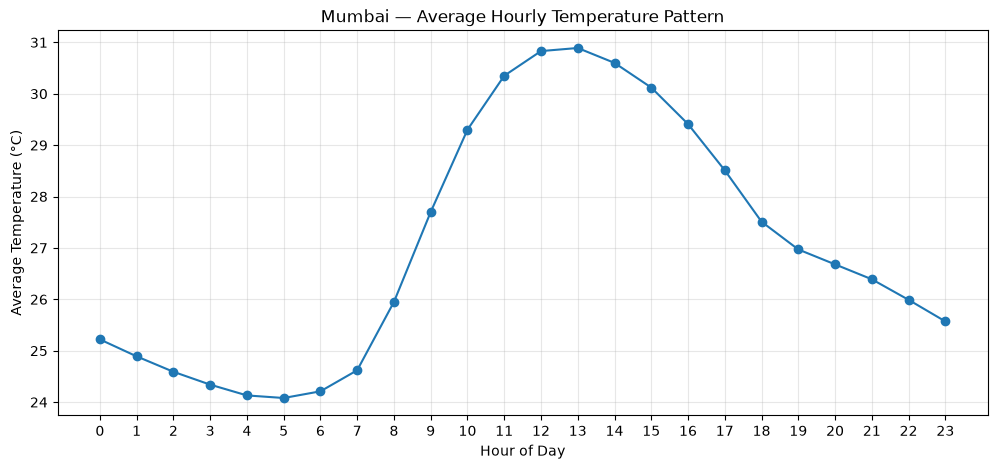

In [38]:
# Mumbai hourly temperature pattern

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    hourly_summary.index,
    hourly_summary["temperature_mean"],
    marker="o"
)

plt.xlabel("Hour of Day")
plt.ylabel("Average Temperature (°C)")
plt.title("Mumbai — Average Hourly Temperature Pattern")

plt.xticks(range(0, 24))

plt.grid(True, alpha=0.3)

plt.show()

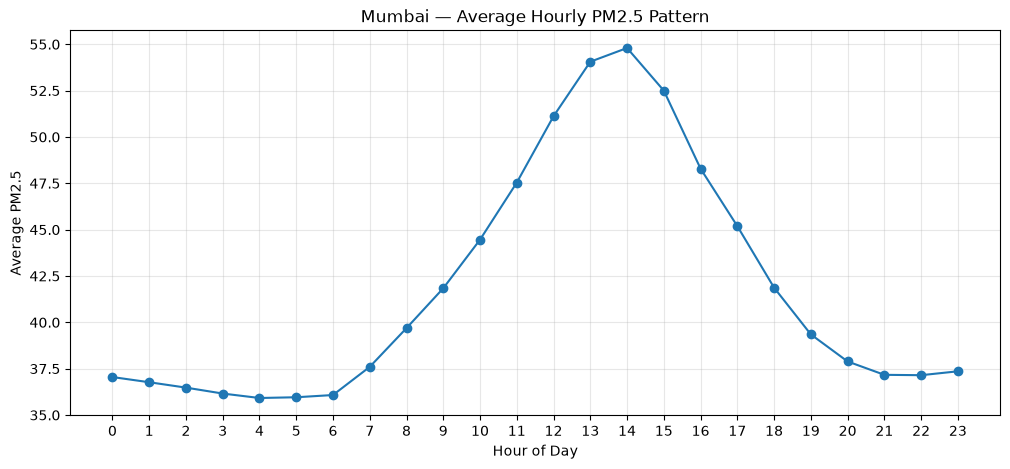

In [39]:
# Mumbai hourly PM2.5 pattern

plt.figure(figsize=(12, 5))

plt.plot(
    hourly_summary.index,
    hourly_summary["pm25_mean"],
    marker="o"
)

plt.xlabel("Hour of Day")
plt.ylabel("Average PM2.5")
plt.title("Mumbai — Average Hourly PM2.5 Pattern")

plt.xticks(range(0, 24))

plt.grid(True, alpha=0.3)

plt.show()

In [40]:
# Inspect extreme PM2.5 observations

extreme_pm25 = (
    mumbai_hourly_df
    .sort_values("pm2_5", ascending=False)
    [
        [
            "time",
            "pm2_5",
            "pm10",
            "carbon_monoxide",
            "nitrogen_dioxide",
            "sulphur_dioxide",
            "ozone",
            "temperature_2m",
            "relative_humidity_2m",
            "wind_speed_10m",
            "pressure_msl",
            "rain"
        ]
    ]
    .head(20)
)

display(extreme_pm25)

,time,pm2_5,pm10,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,temperature_2m,relative_humidity_2m,wind_speed_10m,pressure_msl,rain
5314,2023-03-13 15:00:00,581.1,832.6,2970.0,15.9,145.9,916.0,32.9,39,13.6,1008.4,0.0
5313,2023-03-13 14:00:00,510.4,732.0,2956.0,18.7,142.1,930.0,34.2,39,15.3,1008.8,0.0
5315,2023-03-13 16:00:00,497.3,715.3,2981.0,32.9,156.5,840.0,32.9,40,12.6,1008.2,0.0
5312,2023-03-13 13:00:00,478.7,683.6,2952.0,75.5,155.0,808.0,36.7,22,9.5,1009.4,0.0
5337,2023-03-14 14:00:00,448.0,644.5,2494.0,12.2,45.5,620.0,33.6,40,16.4,1007.4,0.0
5311,2023-03-13 12:00:00,427.5,610.9,2936.0,135.0,170.4,655.0,37.4,19,5.1,1010.5,0.0
5336,2023-03-14 13:00:00,392.1,562.5,2535.0,43.6,113.5,568.0,33.1,48,15.0,1008.4,0.0
5936,2023-04-08 13:00:00,362.3,521.5,2495.0,113.6,157.8,646.0,33.1,48,17.1,1011.9,0.0
5335,2023-03-14 12:00:00,360.4,516.0,2516.0,77.4,184.5,487.0,34.1,39,12.6,1009.6,0.0
5310,2023-03-13 11:00:00,355.8,510.4,2905.0,179.8,183.5,502.0,36.0,23,4.7,1011.4,0.0


In [1]:
# Analyze target distributions

target_columns = [
    "temperature_2m",
    "rain",
    "wind_speed_10m",
    "pressure_msl",
    "relative_humidity_2m",
    "pm2_5",
    "pm10"
]

target_summary = (
    mumbai_hourly_df[target_columns]
    .describe()
    .T
    .round(2)
)

display(target_summary)

NameError: name 'mumbai_hourly_df' is not defined

In [2]:
# Load the cleaned Mumbai dataset

import pandas as pd
from pathlib import Path

data_folder = Path("../data")

csv_files = list(data_folder.rglob("*.csv"))

print("CSV files found:")

for file in csv_files:
    print(file)

CSV files found:
..\data\processed\mumbai_climate_ml.csv
..\data\processed\mumbai_weather_air_quality_hourly.csv
..\data\raw\mumbai_weather_2015_2025.csv
..\data\raw\mumbai_weather_hourly_2022_2025.csv


In [3]:
# Load the clean Mumbai ML dataset

import pandas as pd

mumbai_hourly_df = pd.read_csv(
    "../data/processed/mumbai_climate_ml.csv",
    parse_dates=["time"]
)

print("Mumbai ML dataset loaded successfully!")
print("Shape:", mumbai_hourly_df.shape)
print("Time range:")
print(mumbai_hourly_df["time"].min())
print(mumbai_hourly_df["time"].max())

ValueError: Missing column provided to 'parse_dates': 'time'

In [4]:
# Inspect saved ML dataset

import pandas as pd

df_check = pd.read_csv(
    "../data/processed/mumbai_climate_ml.csv"
)

print("Columns in saved dataset:")
print(df_check.columns.tolist())

print("\nFirst 3 rows:")
display(df_check.head(3))

Columns in saved dataset:
['date', 'temperature', 'rainfall', 'wind_speed', 'pressure', 'humidity', 'pm2_5']

First 3 rows:


,date,temperature,rainfall,wind_speed,pressure,humidity,pm2_5
0,2022-08-04,27.0,13.6,13.3,1003.0,86.833333,25.989474
1,2022-08-05,26.1,27.2,15.1,1001.6,90.250000,16.737500
2,2022-08-06,26.1,33.7,17.1,1000.5,89.333333,18.979167


In [5]:
# Load the Mumbai hourly weather and air-quality dataset

import pandas as pd

mumbai_hourly_df = pd.read_csv(
    "../data/processed/mumbai_weather_air_quality_hourly.csv"
)

mumbai_hourly_df["time"] = pd.to_datetime(
    mumbai_hourly_df["time"]
)

print("Mumbai hourly dataset loaded successfully!")

print("Shape:", mumbai_hourly_df.shape)

print("\nTime range:")
print(mumbai_hourly_df["time"].min())
print(mumbai_hourly_df["time"].max())

print("\nColumns:")
print(mumbai_hourly_df.columns.tolist())

Mumbai hourly dataset loaded successfully!
Shape: (29899, 31)

Time range:
2022-08-04 05:00:00
2025-12-31 23:00:00

Columns:
['time', 'temperature_2m', 'relative_humidity_2m', 'dew_point_2m', 'apparent_temperature', 'precipitation', 'rain', 'weather_code', 'pressure_msl', 'surface_pressure', 'cloud_cover', 'cloud_cover_low', 'cloud_cover_mid', 'cloud_cover_high', 'wind_speed_10m', 'wind_direction_10m', 'wind_gusts_10m', 'vapour_pressure_deficit', 'shortwave_radiation', 'direct_radiation', 'diffuse_radiation', 'sunshine_duration', 'wet_bulb_temperature_2m', 'pm2_5', 'pm10', 'carbon_monoxide', 'nitrogen_dioxide', 'sulphur_dioxide', 'ozone', 'aerosol_optical_depth', 'dust']


In [6]:
# Verify loaded dataset

print("Missing values:",
      mumbai_hourly_df.isna().sum().sum())

print("Duplicate timestamps:",
      mumbai_hourly_df["time"].duplicated().sum())

print(
    "Timestamps sorted:",
    mumbai_hourly_df["time"].is_monotonic_increasing
)

Missing values: 0
Duplicate timestamps: 0
Timestamps sorted: True


In [7]:
# Analyze target distributions

target_columns = [
    "temperature_2m",
    "rain",
    "wind_speed_10m",
    "pressure_msl",
    "relative_humidity_2m",
    "pm2_5",
    "pm10"
]

target_summary = (
    mumbai_hourly_df[target_columns]
    .describe()
    .T
    .round(2)
)

display(target_summary)

,count,mean,std,min,25%,50%,75%,max
temperature_2m,29899.0,27.04,3.38,14.6,25.3,26.7,28.9,41.3
rain,29899.0,0.29,1.01,0.0,0.0,0.0,0.1,25.3
wind_speed_10m,29899.0,11.15,6.10,0.0,6.4,10.0,15.1,42.6
pressure_msl,29899.0,1009.12,3.78,995.4,1006.6,1009.4,1012.0,1019.1
relative_humidity_2m,29899.0,70.84,19.42,9.0,57.0,76.0,87.0,100.0
pm2_5,29899.0,41.76,33.73,0.5,19.8,29.1,55.4,581.1
pm10,29899.0,65.86,45.42,0.7,39.0,53.3,80.1,832.6


In [8]:
# Calculate target skewness

target_skewness = (
    mumbai_hourly_df[target_columns]
    .skew()
    .sort_values(ascending=False)
    .round(3)
)

print("Target skewness:")
display(target_skewness)

Target skewness:


rain                    7.559
pm10                    3.455
pm2_5                   3.079
wind_speed_10m          0.748
temperature_2m          0.081
pressure_msl           -0.339
relative_humidity_2m   -0.716
dtype: float64

In [9]:
# Create temporal features

mumbai_hourly_df["year"] = (
    mumbai_hourly_df["time"].dt.year
)

mumbai_hourly_df["month"] = (
    mumbai_hourly_df["time"].dt.month
)

mumbai_hourly_df["day"] = (
    mumbai_hourly_df["time"].dt.day
)

mumbai_hourly_df["day_of_year"] = (
    mumbai_hourly_df["time"].dt.dayofyear
)

mumbai_hourly_df["day_of_week"] = (
    mumbai_hourly_df["time"].dt.dayofweek
)

mumbai_hourly_df["hour"] = (
    mumbai_hourly_df["time"].dt.hour
)

print("Basic temporal features created!")

print(
    mumbai_hourly_df[
        [
            "time",
            "year",
            "month",
            "day",
            "day_of_year",
            "day_of_week",
            "hour"
        ]
    ].head()
)

Basic temporal features created!
                 time  year  month  day  day_of_year  day_of_week  hour
0 2022-08-04 05:00:00  2022      8    4          216            3     5
1 2022-08-04 06:00:00  2022      8    4          216            3     6
2 2022-08-04 07:00:00  2022      8    4          216            3     7
3 2022-08-04 08:00:00  2022      8    4          216            3     8
4 2022-08-04 09:00:00  2022      8    4          216            3     9


In [10]:
# Create cyclical time features

import numpy as np

mumbai_hourly_df["hour_sin"] = np.sin(
    2 * np.pi * mumbai_hourly_df["hour"] / 24
)

mumbai_hourly_df["hour_cos"] = np.cos(
    2 * np.pi * mumbai_hourly_df["hour"] / 24
)

mumbai_hourly_df["day_of_year_sin"] = np.sin(
    2 * np.pi * mumbai_hourly_df["day_of_year"] / 365.25
)

mumbai_hourly_df["day_of_year_cos"] = np.cos(
    2 * np.pi * mumbai_hourly_df["day_of_year"] / 365.25
)

mumbai_hourly_df["day_of_week_sin"] = np.sin(
    2 * np.pi * mumbai_hourly_df["day_of_week"] / 7
)

mumbai_hourly_df["day_of_week_cos"] = np.cos(
    2 * np.pi * mumbai_hourly_df["day_of_week"] / 7
)

print("Cyclical time features created!")

display(
    mumbai_hourly_df[
        [
            "time",
            "hour",
            "hour_sin",
            "hour_cos",
            "day_of_year",
            "day_of_year_sin",
            "day_of_year_cos",
            "day_of_week_sin",
            "day_of_week_cos"
        ]
    ].head(10)
)

Cyclical time features created!


,time,hour,hour_sin,hour_cos,day_of_year,day_of_year_sin,day_of_year_cos,day_of_week_sin,day_of_week_cos
0,2022-08-04 05:00:00,5,9.659258e-01,2.588190e-01,216,-0.543105,-0.839665,0.433884,-0.900969
1,2022-08-04 06:00:00,6,1.000000e+00,6.123234e-17,216,-0.543105,-0.839665,0.433884,-0.900969
2,2022-08-04 07:00:00,7,9.659258e-01,-2.588190e-01,216,-0.543105,-0.839665,0.433884,-0.900969
3,2022-08-04 08:00:00,8,8.660254e-01,-5.000000e-01,216,-0.543105,-0.839665,0.433884,-0.900969
4,2022-08-04 09:00:00,9,7.071068e-01,-7.071068e-01,216,-0.543105,-0.839665,0.433884,-0.900969
5,2022-08-04 10:00:00,10,5.000000e-01,-8.660254e-01,216,-0.543105,-0.839665,0.433884,-0.900969
6,2022-08-04 11:00:00,11,2.588190e-01,-9.659258e-01,216,-0.543105,-0.839665,0.433884,-0.900969
7,2022-08-04 12:00:00,12,1.224647e-16,-1.000000e+00,216,-0.543105,-0.839665,0.433884,-0.900969
8,2022-08-04 13:00:00,13,-2.588190e-01,-9.659258e-01,216,-0.543105,-0.839665,0.433884,-0.900969
9,2022-08-04 14:00:00,14,-5.000000e-01,-8.660254e-01,216,-0.543105,-0.839665,0.433884,-0.900969


In [11]:
# Create cyclical wind-direction features

mumbai_hourly_df["wind_direction_sin"] = np.sin(
    2 * np.pi * mumbai_hourly_df["wind_direction_10m"] / 360
)

mumbai_hourly_df["wind_direction_cos"] = np.cos(
    2 * np.pi * mumbai_hourly_df["wind_direction_10m"] / 360
)

print("Wind direction cyclical features created!")

display(
    mumbai_hourly_df[
        [
            "time",
            "wind_direction_10m",
            "wind_direction_sin",
            "wind_direction_cos"
        ]
    ].head(10)
)

Wind direction cyclical features created!


,time,wind_direction_10m,wind_direction_sin,wind_direction_cos
0,2022-08-04 05:00:00,225,-0.707107,-7.071068e-01
1,2022-08-04 06:00:00,270,-1.000000,-1.836970e-16
2,2022-08-04 07:00:00,37,0.601815,7.986355e-01
3,2022-08-04 08:00:00,53,0.798636,6.018150e-01
4,2022-08-04 09:00:00,14,0.241922,9.702957e-01
5,2022-08-04 10:00:00,315,-0.707107,7.071068e-01
6,2022-08-04 11:00:00,261,-0.987688,-1.564345e-01
7,2022-08-04 12:00:00,247,-0.920505,-3.907311e-01
8,2022-08-04 13:00:00,254,-0.961262,-2.756374e-01
9,2022-08-04 14:00:00,267,-0.998630,-5.233596e-02


In [12]:
# Create Mumbai seasonal features

mumbai_hourly_df["is_monsoon"] = (
    mumbai_hourly_df["month"].isin([6, 7, 8, 9]).astype(int)
)

mumbai_hourly_df["is_pre_monsoon"] = (
    mumbai_hourly_df["month"].isin([3, 4, 5]).astype(int)
)

mumbai_hourly_df["is_post_monsoon"] = (
    mumbai_hourly_df["month"].isin([10, 11]).astype(int)
)

mumbai_hourly_df["is_winter"] = (
    mumbai_hourly_df["month"].isin([12, 1, 2]).astype(int)
)

print("Mumbai seasonal features created!")

display(
    mumbai_hourly_df[
        [
            "time",
            "month",
            "is_monsoon",
            "is_pre_monsoon",
            "is_post_monsoon",
            "is_winter"
        ]
    ].head(10)
)

Mumbai seasonal features created!


,time,month,is_monsoon,is_pre_monsoon,is_post_monsoon,is_winter
0,2022-08-04 05:00:00,8,1,0,0,0
1,2022-08-04 06:00:00,8,1,0,0,0
2,2022-08-04 07:00:00,8,1,0,0,0
3,2022-08-04 08:00:00,8,1,0,0,0
4,2022-08-04 09:00:00,8,1,0,0,0
5,2022-08-04 10:00:00,8,1,0,0,0
6,2022-08-04 11:00:00,8,1,0,0,0
7,2022-08-04 12:00:00,8,1,0,0,0
8,2022-08-04 13:00:00,8,1,0,0,0
9,2022-08-04 14:00:00,8,1,0,0,0


In [13]:
# Create multi-scale lag features

lag_variables = [
    "temperature_2m",
    "rain",
    "wind_speed_10m",
    "pressure_msl",
    "relative_humidity_2m",
    "pm2_5",
    "pm10",
    "carbon_monoxide",
    "nitrogen_dioxide",
    "sulphur_dioxide",
    "ozone"
]

lag_periods = [
    1,
    3,
    6,
    12,
    24,
    48,
    72,
    168
]

for variable in lag_variables:
    for lag in lag_periods:
        mumbai_hourly_df[
            f"{variable}_lag_{lag}h"
        ] = (
            mumbai_hourly_df[variable]
            .shift(lag)
        )

print("Multi-scale lag features created!")

print(
    "Number of columns:",
    len(mumbai_hourly_df.columns)
)

print("\nExample lag features:")

display(
    mumbai_hourly_df[
        [
            "time",
            "temperature_2m",
            "temperature_2m_lag_1h",
            "temperature_2m_lag_24h",
            "temperature_2m_lag_168h",
            "pm2_5",
            "pm2_5_lag_1h",
            "pm2_5_lag_24h",
            "pm2_5_lag_168h"
        ]
    ].iloc[168:173]
)

Multi-scale lag features created!
Number of columns: 137

Example lag features:


C:\Users\anupa\AppData\Local\Temp\ipykernel_22808\230079522.py:30: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  mumbai_hourly_df[
C:\Users\anupa\AppData\Local\Temp\ipykernel_22808\230079522.py:30: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  mumbai_hourly_df[
C:\Users\anupa\AppData\Local\Temp\ipykernel_22808\230079522.py:30: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=

,time,temperature_2m,temperature_2m_lag_1h,temperature_2m_lag_24h,temperature_2m_lag_168h,pm2_5,pm2_5_lag_1h,pm2_5_lag_24h,pm2_5_lag_168h
168,2022-08-11 05:00:00,25.9,25.8,25.5,26.6,24.2,22.7,22.7,17.6
169,2022-08-11 06:00:00,26.3,25.9,25.9,26.8,24.9,24.2,22.4,17.7
170,2022-08-11 07:00:00,26.4,26.3,25.7,27.0,25.2,24.9,22.9,18.2
171,2022-08-11 08:00:00,26.4,26.4,25.7,27.1,24.9,25.2,24.6,18.9
172,2022-08-11 09:00:00,26.6,26.4,26.1,27.4,25.2,24.9,25.7,22.1


In [14]:
# Create rolling-window features

rolling_variables = [
    "temperature_2m",
    "rain",
    "wind_speed_10m",
    "pressure_msl",
    "relative_humidity_2m",
    "pm2_5",
    "pm10",
    "carbon_monoxide",
    "nitrogen_dioxide",
    "sulphur_dioxide",
    "ozone"
]

rolling_windows = [
    3,
    6,
    12,
    24,
    72,
    168
]

rolling_features = {}

for variable in rolling_variables:

    shifted = mumbai_hourly_df[variable].shift(1)

    for window in rolling_windows:

        rolling_features[
            f"{variable}_rolling_mean_{window}h"
        ] = shifted.rolling(window).mean()

        rolling_features[
            f"{variable}_rolling_std_{window}h"
        ] = shifted.rolling(window).std()

        rolling_features[
            f"{variable}_rolling_min_{window}h"
        ] = shifted.rolling(window).min()

        rolling_features[
            f"{variable}_rolling_max_{window}h"
        ] = shifted.rolling(window).max()

rolling_df = pd.DataFrame(
    rolling_features,
    index=mumbai_hourly_df.index
)

mumbai_hourly_df = pd.concat(
    [mumbai_hourly_df, rolling_df],
    axis=1
)

print("Rolling-window features created!")

print("Number of columns:", len(mumbai_hourly_df.columns))

display(
    mumbai_hourly_df[
        [
            "time",
            "temperature_2m",
            "temperature_2m_rolling_mean_24h",
            "temperature_2m_rolling_std_24h",
            "rain",
            "rain_rolling_mean_24h",
            "rain_rolling_max_24h",
            "pm2_5",
            "pm2_5_rolling_mean_24h",
            "pm2_5_rolling_max_24h"
        ]
    ].iloc[168:173]
)

Rolling-window features created!
Number of columns: 401


,time,temperature_2m,temperature_2m_rolling_mean_24h,temperature_2m_rolling_std_24h,rain,rain_rolling_mean_24h,rain_rolling_max_24h,pm2_5,pm2_5_rolling_mean_24h,pm2_5_rolling_max_24h
168,2022-08-11 05:00:00,25.9,26.162500,0.498530,0.6,1.554167,7.1,24.2,22.783333,28.3
169,2022-08-11 06:00:00,26.3,26.179167,0.481825,0.9,1.541667,7.1,24.9,22.845833,28.3
170,2022-08-11 07:00:00,26.4,26.195833,0.478657,0.5,1.554167,7.1,25.2,22.950000,28.3
171,2022-08-11 08:00:00,26.4,26.225000,0.468346,0.9,1.500000,7.1,24.9,23.045833,28.3
172,2022-08-11 09:00:00,26.6,26.254167,0.455860,0.9,1.454167,7.1,25.2,23.058333,28.3


In [15]:
# Create rainfall-specific features

rainfall_features = pd.DataFrame(
    index=mumbai_hourly_df.index
)

rain_past = mumbai_hourly_df["rain"].shift(1)

# Cumulative rainfall over previous periods

rainfall_features["rain_total_3h"] = (
    rain_past.rolling(3).sum()
)

rainfall_features["rain_total_6h"] = (
    rain_past.rolling(6).sum()
)

rainfall_features["rain_total_12h"] = (
    rain_past.rolling(12).sum()
)

rainfall_features["rain_total_24h"] = (
    rain_past.rolling(24).sum()
)

rainfall_features["rain_total_48h"] = (
    rain_past.rolling(48).sum()
)

rainfall_features["rain_total_72h"] = (
    rain_past.rolling(72).sum()
)

rainfall_features["rain_total_168h"] = (
    rain_past.rolling(168).sum()
)

# Number of rainy hours

rainfall_features["rain_hours_24h"] = (
    (rain_past > 0.1)
    .rolling(24)
    .sum()
)

rainfall_features["rain_hours_72h"] = (
    (rain_past > 0.1)
    .rolling(72)
    .sum()
)

rainfall_features["rain_hours_168h"] = (
    (rain_past > 0.1)
    .rolling(168)
    .sum()
)

# Maximum rainfall intensity

rainfall_features["rain_max_24h"] = (
    rain_past.rolling(24).max()
)

rainfall_features["rain_max_72h"] = (
    rain_past.rolling(72).max()
)

rainfall_features["rain_max_168h"] = (
    rain_past.rolling(168).max()
)

# Recent rainfall indicators

rainfall_features["rained_previous_24h"] = (
    rainfall_features["rain_hours_24h"] > 0
).astype(int)

rainfall_features["rained_previous_72h"] = (
    rainfall_features["rain_hours_72h"] > 0
).astype(int)

mumbai_hourly_df = pd.concat(
    [
        mumbai_hourly_df,
        rainfall_features
    ],
    axis=1
)

print("Rainfall-specific features created!")

print(
    "Number of columns:",
    len(mumbai_hourly_df.columns)
)

display(
    mumbai_hourly_df[
        [
            "time",
            "rain",
            "rain_total_24h",
            "rain_total_72h",
            "rain_total_168h",
            "rain_hours_24h",
            "rain_hours_72h",
            "rain_max_24h",
            "rained_previous_24h"
        ]
    ].iloc[168:173]
)

Rainfall-specific features created!
Number of columns: 416


,time,rain,rain_total_24h,rain_total_72h,rain_total_168h,rain_hours_24h,rain_hours_72h,rain_max_24h,rained_previous_24h
168,2022-08-11 05:00:00,0.6,37.3,135.2,274.9,24.0,72.0,7.1,1
169,2022-08-11 06:00:00,0.9,37.0,134.7,275.3,24.0,72.0,7.1,1
170,2022-08-11 07:00:00,0.5,37.3,133.5,276.1,24.0,72.0,7.1,1
171,2022-08-11 08:00:00,0.9,36.0,133.2,276.6,24.0,72.0,7.1,1
172,2022-08-11 09:00:00,0.9,34.9,132.1,277.4,24.0,72.0,7.1,1


In [16]:
# Create weather and pollution trend features

trend_variables = [
    "temperature_2m",
    "relative_humidity_2m",
    "pressure_msl",
    "wind_speed_10m",
    "pm2_5",
    "pm10",
    "carbon_monoxide",
    "nitrogen_dioxide",
    "sulphur_dioxide",
    "ozone"
]

trend_periods = [
    1,
    3,
    6,
    12,
    24
]

trend_features = {}

for variable in trend_variables:

    for period in trend_periods:

        trend_features[
            f"{variable}_change_{period}h"
        ] = (
            mumbai_hourly_df[variable]
            - mumbai_hourly_df[variable].shift(period)
        )

trend_df = pd.DataFrame(
    trend_features,
    index=mumbai_hourly_df.index
)

mumbai_hourly_df = pd.concat(
    [
        mumbai_hourly_df,
        trend_df
    ],
    axis=1
)

print("Weather and pollution trend features created!")

print(
    "Number of columns:",
    len(mumbai_hourly_df.columns)
)

display(
    mumbai_hourly_df[
        [
            "time",
            "temperature_2m",
            "temperature_2m_change_1h",
            "temperature_2m_change_6h",
            "temperature_2m_change_24h",
            "pressure_msl",
            "pressure_msl_change_3h",
            "wind_speed_10m_change_6h",
            "pm2_5",
            "pm2_5_change_3h",
            "pm2_5_change_24h"
        ]
    ].iloc[168:173]
)

Weather and pollution trend features created!
Number of columns: 466


,time,temperature_2m,temperature_2m_change_1h,temperature_2m_change_6h,temperature_2m_change_24h,pressure_msl,pressure_msl_change_3h,wind_speed_10m_change_6h,pm2_5,pm2_5_change_3h,pm2_5_change_24h
168,2022-08-11 05:00:00,25.9,0.1,-0.5,0.4,997.1,0.2,-2.5,24.2,6.4,1.5
169,2022-08-11 06:00:00,26.3,0.4,0.0,0.4,997.6,0.7,0.1,24.9,5.2,2.5
170,2022-08-11 07:00:00,26.4,0.1,0.7,0.7,998.1,1.2,0.7,25.2,2.5,2.3
171,2022-08-11 08:00:00,26.4,0.0,0.6,0.7,998.9,1.8,0.0,24.9,0.7,0.3
172,2022-08-11 09:00:00,26.6,0.2,0.8,0.5,999.3,1.7,-0.1,25.2,0.3,-0.5


In [17]:
# Create derived atmospheric features

derived_features = pd.DataFrame(
    index=mumbai_hourly_df.index
)

# Temperature and humidity interaction
derived_features["temperature_humidity_index"] = (
    mumbai_hourly_df["temperature_2m"]
    * mumbai_hourly_df["relative_humidity_2m"]
)

# Apparent temperature difference
derived_features["apparent_temperature_difference"] = (
    mumbai_hourly_df["apparent_temperature"]
    - mumbai_hourly_df["temperature_2m"]
)

# Dew-point depression
derived_features["dew_point_depression"] = (
    mumbai_hourly_df["temperature_2m"]
    - mumbai_hourly_df["dew_point_2m"]
)

# Pressure difference between sea-level and surface pressure
derived_features["pressure_difference"] = (
    mumbai_hourly_df["pressure_msl"]
    - mumbai_hourly_df["surface_pressure"]
)

# Wind and humidity interaction
derived_features["wind_humidity_interaction"] = (
    mumbai_hourly_df["wind_speed_10m"]
    * mumbai_hourly_df["relative_humidity_2m"]
)

# Wind gust ratio
derived_features["wind_gust_ratio"] = (
    mumbai_hourly_df["wind_gusts_10m"]
    / (mumbai_hourly_df["wind_speed_10m"] + 0.1)
)

# PM2.5 / PM10 relationship
derived_features["pm25_pm10_ratio"] = (
    mumbai_hourly_df["pm2_5"]
    / (mumbai_hourly_df["pm10"] + 0.1)
)

# Combined pollution indicator
derived_features["pollution_index"] = (
    mumbai_hourly_df["pm2_5"]
    + mumbai_hourly_df["pm10"]
)

# Gas pollution indicator
derived_features["gas_pollution_index"] = (
    mumbai_hourly_df["carbon_monoxide"]
    + mumbai_hourly_df["nitrogen_dioxide"]
    + mumbai_hourly_df["sulphur_dioxide"]
)

# Total cloud cover components
derived_features["cloud_cover_average"] = (
    (
        mumbai_hourly_df["cloud_cover_low"]
        + mumbai_hourly_df["cloud_cover_mid"]
        + mumbai_hourly_df["cloud_cover_high"]
    ) / 3
)

# Radiation total
derived_features["total_radiation"] = (
    mumbai_hourly_df["direct_radiation"]
    + mumbai_hourly_df["diffuse_radiation"]
)

mumbai_hourly_df = pd.concat(
    [
        mumbai_hourly_df,
        derived_features
    ],
    axis=1
)

print("Derived atmospheric features created!")

print(
    "Number of columns:",
    len(mumbai_hourly_df.columns)
)

display(
    mumbai_hourly_df[
        [
            "time",
            "temperature_humidity_index",
            "apparent_temperature_difference",
            "dew_point_depression",
            "pressure_difference",
            "wind_gust_ratio",
            "pm25_pm10_ratio",
            "pollution_index",
            "gas_pollution_index",
            "cloud_cover_average",
            "total_radiation"
        ]
    ].iloc[168:173]
)

Derived atmospheric features created!
Number of columns: 477


,time,temperature_humidity_index,apparent_temperature_difference,dew_point_depression,pressure_difference,wind_gust_ratio,pm25_pm10_ratio,pollution_index,gas_pollution_index,cloud_cover_average,total_radiation
168,2022-08-11 05:00:00,2279.2,1.7,2.2,0.7,2.079585,0.587379,65.3,134.8,66.333333,0.0
169,2022-08-11 06:00:00,2261.8,1.4,2.5,0.7,1.685897,0.565909,68.8,162.5,61.000000,0.0
170,2022-08-11 07:00:00,2270.4,1.7,2.4,0.7,1.847682,0.555066,70.5,201.2,46.000000,39.0
171,2022-08-11 08:00:00,2244.0,1.2,2.8,0.7,1.745342,0.550885,70.0,238.6,86.333333,143.0
172,2022-08-11 09:00:00,2287.6,1.4,2.6,0.7,1.776730,0.549020,71.0,241.2,64.666667,267.0


In [18]:
# Create next-hour prediction targets

target_mapping = {
    "temperature_2m": "target_temperature",
    "rain": "target_rain",
    "wind_speed_10m": "target_wind_speed",
    "pressure_msl": "target_pressure",
    "relative_humidity_2m": "target_humidity",
    "pm2_5": "target_pm2_5"
}

target_features = pd.DataFrame(
    index=mumbai_hourly_df.index
)

for source, target in target_mapping.items():

    target_features[target] = (
        mumbai_hourly_df[source].shift(-1)
    )

# Rain occurrence target for Approach B

target_features["target_rain_occurrence"] = (
    target_features["target_rain"] > 0.1
).astype(int)

mumbai_hourly_df = pd.concat(
    [
        mumbai_hourly_df,
        target_features
    ],
    axis=1
)

print("Next-hour prediction targets created!")

print("Number of columns:", len(mumbai_hourly_df.columns))

display(
    mumbai_hourly_df[
        [
            "time",
            "temperature_2m",
            "target_temperature",
            "rain",
            "target_rain",
            "target_rain_occurrence",
            "wind_speed_10m",
            "target_wind_speed",
            "pm2_5",
            "target_pm2_5"
        ]
    ].iloc[168:173]
)

Next-hour prediction targets created!
Number of columns: 484


,time,temperature_2m,target_temperature,rain,target_rain,target_rain_occurrence,wind_speed_10m,target_wind_speed,pm2_5,target_pm2_5
168,2022-08-11 05:00:00,25.9,26.3,0.6,0.9,1,28.8,31.1,24.2,24.9
169,2022-08-11 06:00:00,26.3,26.4,0.9,0.5,1,31.1,30.1,24.9,25.2
170,2022-08-11 07:00:00,26.4,26.4,0.5,0.9,1,30.1,32.1,25.2,24.9
171,2022-08-11 08:00:00,26.4,26.6,0.9,0.9,1,32.1,31.7,24.9,25.2
172,2022-08-11 09:00:00,26.6,27.2,0.9,0.4,1,31.7,33.3,25.2,25.0


In [19]:
# Analyze rainfall occurrence target

rain_occurrence_counts = (
    mumbai_hourly_df["target_rain_occurrence"]
    .value_counts()
    .sort_index()
)

print("Rainfall occurrence distribution:")
display(rain_occurrence_counts)

print("\nRainfall occurrence percentage:")

rain_occurrence_percentage = (
    mumbai_hourly_df["target_rain_occurrence"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

display(rain_occurrence_percentage)

Rainfall occurrence distribution:


target_rain_occurrence
0    23401
1     6498
Name: count, dtype: int64


Rainfall occurrence percentage:


target_rain_occurrence
0    78.27
1    21.73
Name: proportion, dtype: float64

In [20]:
# Analyze positive rainfall amounts

positive_rain = (
    mumbai_hourly_df.loc[
        mumbai_hourly_df["target_rain"] > 0.1,
        "target_rain"
    ]
)

print("Rainy-hour observations:", len(positive_rain))

print("\nPositive rainfall statistics:")

display(
    positive_rain.describe().round(2)
)

Rainy-hour observations: 6498

Positive rainfall statistics:


count    6498.00
mean        1.29
std         1.84
min         0.20
25%         0.30
50%         0.60
75%         1.50
max        25.30
Name: target_rain, dtype: float64

In [21]:
# Final feature dataset cleanup

import numpy as np

print("Shape before cleanup:", mumbai_hourly_df.shape)

# Replace infinite values with NaN

mumbai_hourly_df = mumbai_hourly_df.replace(
    [np.inf, -np.inf],
    np.nan
)

# Remove rows with missing values caused by
# lag, rolling, or next-hour target creation

mumbai_ml_df = (
    mumbai_hourly_df
    .dropna()
    .reset_index(drop=True)
)

print("Shape after cleanup:", mumbai_ml_df.shape)

print(
    "Missing values:",
    mumbai_ml_df.isna().sum().sum()
)

print(
    "Infinite values:",
    np.isinf(
        mumbai_ml_df.select_dtypes(
            include=np.number
        )
    ).sum().sum()
)

print(
    "Duplicate timestamps:",
    mumbai_ml_df["time"].duplicated().sum()
)

print(
    "Timestamps sorted:",
    mumbai_ml_df["time"].is_monotonic_increasing
)

print("\nFinal time range:")

print(mumbai_ml_df["time"].min())
print(mumbai_ml_df["time"].max())

Shape before cleanup: (29899, 484)
Shape after cleanup: (29730, 484)
Missing values: 0
Infinite values: 0
Duplicate timestamps: 0
Timestamps sorted: True

Final time range:
2022-08-11 05:00:00
2025-12-31 22:00:00


In [22]:
# Create chronological train/validation/test split

n = len(mumbai_ml_df)

train_end = int(n * 0.70)
validation_end = int(n * 0.85)

train_df = mumbai_ml_df.iloc[:train_end].copy()

validation_df = mumbai_ml_df.iloc[
    train_end:validation_end
].copy()

test_df = mumbai_ml_df.iloc[
    validation_end:
].copy()

print("Chronological split completed!")

print("\nDataset sizes:")
print("Total:", len(mumbai_ml_df))
print("Training:", len(train_df))
print("Validation:", len(validation_df))
print("Test:", len(test_df))

print("\nTime ranges:")

print(
    "\nTraining:"
)
print(train_df["time"].min())
print(train_df["time"].max())

print(
    "\nValidation:"
)
print(validation_df["time"].min())
print(validation_df["time"].max())

print(
    "\nTest:"
)
print(test_df["time"].min())
print(test_df["time"].max())

Chronological split completed!

Dataset sizes:
Total: 29730
Training: 20811
Validation: 4459
Test: 4460

Time ranges:

Training:
2022-08-11 05:00:00
2024-12-25 07:00:00

Validation:
2024-12-25 08:00:00
2025-06-29 02:00:00

Test:
2025-06-29 03:00:00
2025-12-31 22:00:00


In [23]:
# Separate features and prediction targets

target_columns = [
    "target_temperature",
    "target_rain",
    "target_rain_occurrence",
    "target_wind_speed",
    "target_pressure",
    "target_humidity",
    "target_pm2_5"
]

# Columns that must never be used as model inputs

excluded_columns = [
    "time",
    "target_temperature",
    "target_rain",
    "target_rain_occurrence",
    "target_wind_speed",
    "target_pressure",
    "target_humidity",
    "target_pm2_5"
]

feature_columns = [
    column
    for column in mumbai_ml_df.columns
    if column not in excluded_columns
]

print("Feature-target separation completed!")

print("Number of input features:", len(feature_columns))

print("\nNumber of targets:", len(target_columns))

print("\nTargets:")
for target in target_columns:
    print("-", target)

print("\nFirst 20 input features:")
print(feature_columns[:20])

print("\nTarget columns accidentally included in features:")

print(
    [
        column
        for column in feature_columns
        if column in target_columns
    ]
)

Feature-target separation completed!
Number of input features: 476

Number of targets: 7

Targets:
- target_temperature
- target_rain
- target_rain_occurrence
- target_wind_speed
- target_pressure
- target_humidity
- target_pm2_5

First 20 input features:
['temperature_2m', 'relative_humidity_2m', 'dew_point_2m', 'apparent_temperature', 'precipitation', 'rain', 'weather_code', 'pressure_msl', 'surface_pressure', 'cloud_cover', 'cloud_cover_low', 'cloud_cover_mid', 'cloud_cover_high', 'wind_speed_10m', 'wind_direction_10m', 'wind_gusts_10m', 'vapour_pressure_deficit', 'shortwave_radiation', 'direct_radiation', 'diffuse_radiation']

Target columns accidentally included in features:
[]


In [24]:
# Create X and y datasets

X_train = train_df[feature_columns].copy()
X_validation = validation_df[feature_columns].copy()
X_test = test_df[feature_columns].copy()

y_train = train_df[target_columns].copy()
y_validation = validation_df[target_columns].copy()
y_test = test_df[target_columns].copy()

print("X/y datasets created successfully!")

print("\nShapes:")
print("X_train:", X_train.shape)
print("X_validation:", X_validation.shape)
print("X_test:", X_test.shape)

print("\ny_train:", y_train.shape)
print("y_validation:", y_validation.shape)
print("y_test:", y_test.shape)

print("\nFeature count:", len(feature_columns))
print("Target count:", len(target_columns))

X/y datasets created successfully!

Shapes:
X_train: (20811, 476)
X_validation: (4459, 476)
X_test: (4460, 476)

y_train: (20811, 7)
y_validation: (4459, 7)
y_test: (4460, 7)

Feature count: 476
Target count: 7


In [25]:
# Verify feature and target separation

print("Target columns present in X_train:")

leakage_columns = [
    column
    for column in X_train.columns
    if column in target_columns
]

print(leakage_columns)

print("\nNaN values:")
print("X_train:", X_train.isna().sum().sum())
print("X_validation:", X_validation.isna().sum().sum())
print("X_test:", X_test.isna().sum().sum())

print("\nInfinite values:")

import numpy as np

print(
    "X_train:",
    np.isinf(X_train.select_dtypes(include=np.number)).sum().sum()
)

print(
    "X_validation:",
    np.isinf(X_validation.select_dtypes(include=np.number)).sum().sum()
)

print(
    "X_test:",
    np.isinf(X_test.select_dtypes(include=np.number)).sum().sum()
)

Target columns present in X_train:
[]

NaN values:
X_train: 0
X_validation: 0
X_test: 0

Infinite values:
X_train: 0
X_validation: 0
X_test: 0


In [26]:
# Prepare final candidate feature set

features_to_remove = [
    "wind_direction_10m"
]

model_features = [
    feature
    for feature in feature_columns
    if feature not in features_to_remove
]

print("Candidate feature set created!")

print("Original features:", len(feature_columns))
print("Removed features:", len(features_to_remove))
print("Model features:", len(model_features))

print("\nRemoved:")
for feature in features_to_remove:
    print("-", feature)

Candidate feature set created!
Original features: 476
Removed features: 1
Model features: 475

Removed:
- wind_direction_10m


In [27]:
# Create model-ready X datasets

X_train_model = train_df[model_features].copy()
X_validation_model = validation_df[model_features].copy()
X_test_model = test_df[model_features].copy()

print("Model-ready datasets created!")

print("X_train:", X_train_model.shape)
print("X_validation:", X_validation_model.shape)
print("X_test:", X_test_model.shape)

Model-ready datasets created!
X_train: (20811, 475)
X_validation: (4459, 475)
X_test: (4460, 475)


In [29]:
# Train Random Forest baseline for temperature

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import time

rf_temperature = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

start_time = time.time()

rf_temperature.fit(
    X_train_model,
    y_train["target_temperature"]
)

training_time = time.time() - start_time

# Validation prediction

rf_temperature_pred = rf_temperature.predict(
    X_validation_model
)

# Metrics

rf_mae = mean_absolute_error(
    y_validation["target_temperature"],
    rf_temperature_pred
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_validation["target_temperature"],
        rf_temperature_pred
    )
)

rf_r2 = r2_score(
    y_validation["target_temperature"],
    rf_temperature_pred
)

print("Random Forest — Temperature")
print("=" * 45)

print(f"MAE  : {rf_mae:.4f} °C")
print(f"RMSE : {rf_rmse:.4f} °C")
print(f"R²   : {rf_r2:.4f}")
print(f"Training time: {training_time:.2f} seconds")

Random Forest — Temperature
MAE  : 0.3577 °C
RMSE : 0.5162 °C
R²   : 0.9774
Training time: 109.62 seconds


In [30]:
# Train Extra Trees baseline for temperature

from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import time

extra_temperature = ExtraTreesRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

start_time = time.time()

extra_temperature.fit(
    X_train_model,
    y_train["target_temperature"]
)

training_time = time.time() - start_time

# Validation prediction

extra_temperature_pred = extra_temperature.predict(
    X_validation_model
)

# Metrics

extra_mae = mean_absolute_error(
    y_validation["target_temperature"],
    extra_temperature_pred
)

extra_rmse = np.sqrt(
    mean_squared_error(
        y_validation["target_temperature"],
        extra_temperature_pred
    )
)

extra_r2 = r2_score(
    y_validation["target_temperature"],
    extra_temperature_pred
)

print("Extra Trees — Temperature")
print("=" * 45)

print(f"MAE  : {extra_mae:.4f} °C")
print(f"RMSE : {extra_rmse:.4f} °C")
print(f"R²   : {extra_r2:.4f}")
print(f"Training time: {training_time:.2f} seconds")

Extra Trees — Temperature
MAE  : 0.3253 °C
RMSE : 0.4699 °C
R²   : 0.9813
Training time: 53.54 seconds


In [2]:
# Load the processed Mumbai ML dataset

import pandas as pd

mumbai_ml_df = pd.read_csv(
    "../data/processed/mumbai_climate_ml.csv"
)

print("Dataset loaded!")
print("Shape:", mumbai_ml_df.shape)
print("\nColumns:")
print(mumbai_ml_df.columns.tolist())

Dataset loaded!
Shape: (1246, 7)

Columns:
['date', 'temperature', 'rainfall', 'wind_speed', 'pressure', 'humidity', 'pm2_5']


In [3]:
# Check processed CSV files

import os
import pandas as pd

processed_path = "../data/processed"

for filename in os.listdir(processed_path):

    if filename.endswith(".csv"):

        path = os.path.join(processed_path, filename)

        df_check = pd.read_csv(path, nrows=5)

        print("\nFile:", filename)
        print("Columns:", len(df_check.columns))
        print("First columns:", df_check.columns.tolist()[:10])


File: mumbai_climate_ml.csv
Columns: 7
First columns: ['date', 'temperature', 'rainfall', 'wind_speed', 'pressure', 'humidity', 'pm2_5']

File: mumbai_weather_air_quality_hourly.csv
Columns: 31
First columns: ['time', 'temperature_2m', 'relative_humidity_2m', 'dew_point_2m', 'apparent_temperature', 'precipitation', 'rain', 'weather_code', 'pressure_msl', 'surface_pressure']


In [4]:
# Load the clean Mumbai hourly weather + air-quality dataset

import pandas as pd

mumbai_hourly_df = pd.read_csv(
    "../data/processed/mumbai_weather_air_quality_hourly.csv",
    parse_dates=["time"]
)

print("Mumbai hourly dataset loaded successfully!")

print("\nShape:")
print(mumbai_hourly_df.shape)

print("\nTime range:")
print(mumbai_hourly_df["time"].min())
print(mumbai_hourly_df["time"].max())

print("\nMissing values:")
print(mumbai_hourly_df.isna().sum().sum())

print("\nDuplicate timestamps:")
print(mumbai_hourly_df["time"].duplicated().sum())

print("\nTimestamps sorted:")
print(mumbai_hourly_df["time"].is_monotonic_increasing)

print("\nColumns:")
print(mumbai_hourly_df.columns.tolist())

Mumbai hourly dataset loaded successfully!

Shape:
(29899, 31)

Time range:
2022-08-04 05:00:00
2025-12-31 23:00:00

Missing values:
0

Duplicate timestamps:
0

Timestamps sorted:
True

Columns:
['time', 'temperature_2m', 'relative_humidity_2m', 'dew_point_2m', 'apparent_temperature', 'precipitation', 'rain', 'weather_code', 'pressure_msl', 'surface_pressure', 'cloud_cover', 'cloud_cover_low', 'cloud_cover_mid', 'cloud_cover_high', 'wind_speed_10m', 'wind_direction_10m', 'wind_gusts_10m', 'vapour_pressure_deficit', 'shortwave_radiation', 'direct_radiation', 'diffuse_radiation', 'sunshine_duration', 'wet_bulb_temperature_2m', 'pm2_5', 'pm10', 'carbon_monoxide', 'nitrogen_dioxide', 'sulphur_dioxide', 'ozone', 'aerosol_optical_depth', 'dust']


In [5]:
# Create temporal, cyclical and Mumbai seasonal features

import numpy as np

# Basic temporal features

mumbai_hourly_df["year"] = mumbai_hourly_df["time"].dt.year
mumbai_hourly_df["month"] = mumbai_hourly_df["time"].dt.month
mumbai_hourly_df["day"] = mumbai_hourly_df["time"].dt.day
mumbai_hourly_df["day_of_year"] = mumbai_hourly_df["time"].dt.dayofyear
mumbai_hourly_df["day_of_week"] = mumbai_hourly_df["time"].dt.dayofweek
mumbai_hourly_df["hour"] = mumbai_hourly_df["time"].dt.hour

# Cyclical hour features

mumbai_hourly_df["hour_sin"] = np.sin(
    2 * np.pi * mumbai_hourly_df["hour"] / 24
)

mumbai_hourly_df["hour_cos"] = np.cos(
    2 * np.pi * mumbai_hourly_df["hour"] / 24
)

# Cyclical day-of-year features

mumbai_hourly_df["day_of_year_sin"] = np.sin(
    2 * np.pi * mumbai_hourly_df["day_of_year"] / 365.25
)

mumbai_hourly_df["day_of_year_cos"] = np.cos(
    2 * np.pi * mumbai_hourly_df["day_of_year"] / 365.25
)

# Cyclical day-of-week features

mumbai_hourly_df["day_of_week_sin"] = np.sin(
    2 * np.pi * mumbai_hourly_df["day_of_week"] / 7
)

mumbai_hourly_df["day_of_week_cos"] = np.cos(
    2 * np.pi * mumbai_hourly_df["day_of_week"] / 7
)

# Wind-direction cyclical features

wind_radians = np.deg2rad(
    mumbai_hourly_df["wind_direction_10m"]
)

mumbai_hourly_df["wind_direction_sin"] = np.sin(
    wind_radians
)

mumbai_hourly_df["wind_direction_cos"] = np.cos(
    wind_radians
)

# Mumbai seasonal features

mumbai_hourly_df["is_monsoon"] = (
    mumbai_hourly_df["month"].isin([6, 7, 8, 9])
).astype(int)

mumbai_hourly_df["is_pre_monsoon"] = (
    mumbai_hourly_df["month"].isin([3, 4, 5])
).astype(int)

mumbai_hourly_df["is_post_monsoon"] = (
    mumbai_hourly_df["month"].isin([10, 11])
).astype(int)

mumbai_hourly_df["is_winter"] = (
    mumbai_hourly_df["month"].isin([12, 1, 2])
).astype(int)

print("Temporal, cyclical and Mumbai seasonal features created!")

print("Dataset shape:", mumbai_hourly_df.shape)
print("Number of columns:", len(mumbai_hourly_df.columns))

display(
    mumbai_hourly_df[
        [
            "time",
            "hour",
            "hour_sin",
            "hour_cos",
            "day_of_year_sin",
            "day_of_year_cos",
            "wind_direction_sin",
            "wind_direction_cos",
            "is_monsoon",
            "is_pre_monsoon",
            "is_post_monsoon",
            "is_winter"
        ]
    ].head()
)

Temporal, cyclical and Mumbai seasonal features created!
Dataset shape: (29899, 49)
Number of columns: 49


,time,hour,hour_sin,hour_cos,day_of_year_sin,day_of_year_cos,wind_direction_sin,wind_direction_cos,is_monsoon,is_pre_monsoon,is_post_monsoon,is_winter
0,2022-08-04 05:00:00,5,0.965926,2.588190e-01,-0.543105,-0.839665,-0.707107,-7.071068e-01,1,0,0,0
1,2022-08-04 06:00:00,6,1.000000,6.123234e-17,-0.543105,-0.839665,-1.000000,-1.836970e-16,1,0,0,0
2,2022-08-04 07:00:00,7,0.965926,-2.588190e-01,-0.543105,-0.839665,0.601815,7.986355e-01,1,0,0,0
3,2022-08-04 08:00:00,8,0.866025,-5.000000e-01,-0.543105,-0.839665,0.798636,6.018150e-01,1,0,0,0
4,2022-08-04 09:00:00,9,0.707107,-7.071068e-01,-0.543105,-0.839665,0.241922,9.702957e-01,1,0,0,0


In [6]:
# Create multi-scale lag features

lag_variables = [
    "temperature_2m",
    "rain",
    "wind_speed_10m",
    "pressure_msl",
    "relative_humidity_2m",
    "pm2_5",
    "pm10",
    "carbon_monoxide",
    "nitrogen_dioxide",
    "sulphur_dioxide",
    "ozone"
]

lag_periods = [1, 3, 6, 12, 24, 48, 72, 168]

lag_features = {}

for variable in lag_variables:
    for lag in lag_periods:
        lag_features[f"{variable}_lag_{lag}h"] = (
            mumbai_hourly_df[variable].shift(lag)
        )

lag_df = pd.DataFrame(
    lag_features,
    index=mumbai_hourly_df.index
)

mumbai_hourly_df = pd.concat(
    [mumbai_hourly_df, lag_df],
    axis=1
)

print("Multi-scale lag features created!")

print("Dataset shape:", mumbai_hourly_df.shape)
print("Number of columns:", len(mumbai_hourly_df.columns))

display(
    mumbai_hourly_df[
        [
            "time",
            "temperature_2m",
            "temperature_2m_lag_1h",
            "temperature_2m_lag_24h",
            "temperature_2m_lag_168h",
            "pm2_5",
            "pm2_5_lag_1h",
            "pm2_5_lag_24h",
            "pm2_5_lag_168h"
        ]
    ].iloc[168:173]
)

Multi-scale lag features created!
Dataset shape: (29899, 137)
Number of columns: 137


,time,temperature_2m,temperature_2m_lag_1h,temperature_2m_lag_24h,temperature_2m_lag_168h,pm2_5,pm2_5_lag_1h,pm2_5_lag_24h,pm2_5_lag_168h
168,2022-08-11 05:00:00,25.9,25.8,25.5,26.6,24.2,22.7,22.7,17.6
169,2022-08-11 06:00:00,26.3,25.9,25.9,26.8,24.9,24.2,22.4,17.7
170,2022-08-11 07:00:00,26.4,26.3,25.7,27.0,25.2,24.9,22.9,18.2
171,2022-08-11 08:00:00,26.4,26.4,25.7,27.1,24.9,25.2,24.6,18.9
172,2022-08-11 09:00:00,26.6,26.4,26.1,27.4,25.2,24.9,25.7,22.1


In [7]:
# Create rolling-window features

rolling_variables = [
    "temperature_2m",
    "rain",
    "wind_speed_10m",
    "pressure_msl",
    "relative_humidity_2m",
    "pm2_5",
    "pm10",
    "carbon_monoxide",
    "nitrogen_dioxide",
    "sulphur_dioxide",
    "ozone"
]

rolling_windows = [3, 6, 12, 24, 72, 168]

rolling_features = {}

for variable in rolling_variables:

    past_values = mumbai_hourly_df[variable].shift(1)

    for window in rolling_windows:

        rolling_features[
            f"{variable}_rolling_mean_{window}h"
        ] = past_values.rolling(window).mean()

        rolling_features[
            f"{variable}_rolling_std_{window}h"
        ] = past_values.rolling(window).std()

        rolling_features[
            f"{variable}_rolling_min_{window}h"
        ] = past_values.rolling(window).min()

        rolling_features[
            f"{variable}_rolling_max_{window}h"
        ] = past_values.rolling(window).max()

rolling_df = pd.DataFrame(
    rolling_features,
    index=mumbai_hourly_df.index
)

mumbai_hourly_df = pd.concat(
    [mumbai_hourly_df, rolling_df],
    axis=1
)

print("Rolling-window features created!")

print("Dataset shape:", mumbai_hourly_df.shape)
print("Number of columns:", len(mumbai_hourly_df.columns))

display(
    mumbai_hourly_df[
        [
            "time",
            "temperature_2m",
            "temperature_2m_rolling_mean_24h",
            "temperature_2m_rolling_std_24h",
            "rain",
            "rain_rolling_mean_24h",
            "rain_rolling_max_24h",
            "pm2_5",
            "pm2_5_rolling_mean_24h",
            "pm2_5_rolling_max_24h"
        ]
    ].iloc[168:173]
)

Rolling-window features created!
Dataset shape: (29899, 401)
Number of columns: 401


,time,temperature_2m,temperature_2m_rolling_mean_24h,temperature_2m_rolling_std_24h,rain,rain_rolling_mean_24h,rain_rolling_max_24h,pm2_5,pm2_5_rolling_mean_24h,pm2_5_rolling_max_24h
168,2022-08-11 05:00:00,25.9,26.162500,0.498530,0.6,1.554167,7.1,24.2,22.783333,28.3
169,2022-08-11 06:00:00,26.3,26.179167,0.481825,0.9,1.541667,7.1,24.9,22.845833,28.3
170,2022-08-11 07:00:00,26.4,26.195833,0.478657,0.5,1.554167,7.1,25.2,22.950000,28.3
171,2022-08-11 08:00:00,26.4,26.225000,0.468346,0.9,1.500000,7.1,24.9,23.045833,28.3
172,2022-08-11 09:00:00,26.6,26.254167,0.455860,0.9,1.454167,7.1,25.2,23.058333,28.3


In [9]:
# Save feature-engineering checkpoint

import os

os.makedirs("../data/processed", exist_ok=True)

checkpoint_path = (
    "../data/processed/"
    "mumbai_ml_features_checkpoint.csv"
)

mumbai_hourly_df.to_csv(
    checkpoint_path,
    index=False
)

print("Feature-engineering checkpoint saved!")
print("Path:", checkpoint_path)
print("Shape:", mumbai_hourly_df.shape)

Feature-engineering checkpoint saved!
Path: ../data/processed/mumbai_ml_features_checkpoint.csv
Shape: (29899, 401)


In [10]:
# Create rainfall-specific features

rainfall_features = pd.DataFrame(
    index=mumbai_hourly_df.index
)

rain_past = mumbai_hourly_df["rain"].shift(1)

# Cumulative rainfall

rainfall_features["rain_total_3h"] = (
    rain_past.rolling(3).sum()
)

rainfall_features["rain_total_6h"] = (
    rain_past.rolling(6).sum()
)

rainfall_features["rain_total_12h"] = (
    rain_past.rolling(12).sum()
)

rainfall_features["rain_total_24h"] = (
    rain_past.rolling(24).sum()
)

rainfall_features["rain_total_48h"] = (
    rain_past.rolling(48).sum()
)

rainfall_features["rain_total_72h"] = (
    rain_past.rolling(72).sum()
)

rainfall_features["rain_total_168h"] = (
    rain_past.rolling(168).sum()
)

# Number of rainy hours

rainfall_features["rain_hours_24h"] = (
    (rain_past > 0.1).rolling(24).sum()
)

rainfall_features["rain_hours_72h"] = (
    (rain_past > 0.1).rolling(72).sum()
)

rainfall_features["rain_hours_168h"] = (
    (rain_past > 0.1).rolling(168).sum()
)

# Maximum rainfall intensity

rainfall_features["rain_max_24h"] = (
    rain_past.rolling(24).max()
)

rainfall_features["rain_max_72h"] = (
    rain_past.rolling(72).max()
)

rainfall_features["rain_max_168h"] = (
    rain_past.rolling(168).max()
)

# Recent rainfall indicators

rainfall_features["rained_previous_24h"] = (
    rainfall_features["rain_hours_24h"] > 0
).astype(int)

rainfall_features["rained_previous_72h"] = (
    rainfall_features["rain_hours_72h"] > 0
).astype(int)

mumbai_hourly_df = pd.concat(
    [
        mumbai_hourly_df,
        rainfall_features
    ],
    axis=1
)

print("Rainfall-specific features created!")

print("Dataset shape:", mumbai_hourly_df.shape)
print("Number of columns:", len(mumbai_hourly_df.columns))

display(
    mumbai_hourly_df[
        [
            "time",
            "rain",
            "rain_total_24h",
            "rain_total_72h",
            "rain_total_168h",
            "rain_hours_24h",
            "rain_hours_72h",
            "rain_max_24h",
            "rained_previous_24h"
        ]
    ].iloc[168:173]
)

Rainfall-specific features created!
Dataset shape: (29899, 416)
Number of columns: 416


,time,rain,rain_total_24h,rain_total_72h,rain_total_168h,rain_hours_24h,rain_hours_72h,rain_max_24h,rained_previous_24h
168,2022-08-11 05:00:00,0.6,37.3,135.2,274.9,24.0,72.0,7.1,1
169,2022-08-11 06:00:00,0.9,37.0,134.7,275.3,24.0,72.0,7.1,1
170,2022-08-11 07:00:00,0.5,37.3,133.5,276.1,24.0,72.0,7.1,1
171,2022-08-11 08:00:00,0.9,36.0,133.2,276.6,24.0,72.0,7.1,1
172,2022-08-11 09:00:00,0.9,34.9,132.1,277.4,24.0,72.0,7.1,1


In [11]:
# Create weather and pollution trend features

trend_variables = [
    "temperature_2m",
    "relative_humidity_2m",
    "pressure_msl",
    "wind_speed_10m",
    "pm2_5",
    "pm10",
    "carbon_monoxide",
    "nitrogen_dioxide",
    "sulphur_dioxide",
    "ozone"
]

trend_periods = [1, 3, 6, 12, 24]

trend_features = {}

for variable in trend_variables:
    for period in trend_periods:
        trend_features[
            f"{variable}_change_{period}h"
        ] = (
            mumbai_hourly_df[variable]
            - mumbai_hourly_df[variable].shift(period)
        )

trend_df = pd.DataFrame(
    trend_features,
    index=mumbai_hourly_df.index
)

mumbai_hourly_df = pd.concat(
    [
        mumbai_hourly_df,
        trend_df
    ],
    axis=1
)

print("Weather and pollution trend features created!")

print("Dataset shape:", mumbai_hourly_df.shape)
print("Number of columns:", len(mumbai_hourly_df.columns))

display(
    mumbai_hourly_df[
        [
            "time",
            "temperature_2m",
            "temperature_2m_change_1h",
            "temperature_2m_change_6h",
            "temperature_2m_change_24h",
            "pressure_msl",
            "pressure_msl_change_3h",
            "wind_speed_10m_change_6h",
            "pm2_5",
            "pm2_5_change_3h",
            "pm2_5_change_24h"
        ]
    ].iloc[168:173]
)

Weather and pollution trend features created!
Dataset shape: (29899, 466)
Number of columns: 466


,time,temperature_2m,temperature_2m_change_1h,temperature_2m_change_6h,temperature_2m_change_24h,pressure_msl,pressure_msl_change_3h,wind_speed_10m_change_6h,pm2_5,pm2_5_change_3h,pm2_5_change_24h
168,2022-08-11 05:00:00,25.9,0.1,-0.5,0.4,997.1,0.2,-2.5,24.2,6.4,1.5
169,2022-08-11 06:00:00,26.3,0.4,0.0,0.4,997.6,0.7,0.1,24.9,5.2,2.5
170,2022-08-11 07:00:00,26.4,0.1,0.7,0.7,998.1,1.2,0.7,25.2,2.5,2.3
171,2022-08-11 08:00:00,26.4,0.0,0.6,0.7,998.9,1.8,0.0,24.9,0.7,0.3
172,2022-08-11 09:00:00,26.6,0.2,0.8,0.5,999.3,1.7,-0.1,25.2,0.3,-0.5


In [12]:
# Create derived atmospheric features

derived_features = pd.DataFrame(
    index=mumbai_hourly_df.index
)

# Temperature and humidity interaction
derived_features["temperature_humidity_index"] = (
    mumbai_hourly_df["temperature_2m"]
    * mumbai_hourly_df["relative_humidity_2m"]
)

# Apparent temperature difference
derived_features["apparent_temperature_difference"] = (
    mumbai_hourly_df["apparent_temperature"]
    - mumbai_hourly_df["temperature_2m"]
)

# Dew-point depression
derived_features["dew_point_depression"] = (
    mumbai_hourly_df["temperature_2m"]
    - mumbai_hourly_df["dew_point_2m"]
)

# Sea-level and surface pressure difference
derived_features["pressure_difference"] = (
    mumbai_hourly_df["pressure_msl"]
    - mumbai_hourly_df["surface_pressure"]
)

# Wind and humidity interaction
derived_features["wind_humidity_interaction"] = (
    mumbai_hourly_df["wind_speed_10m"]
    * mumbai_hourly_df["relative_humidity_2m"]
)

# Wind gust ratio
derived_features["wind_gust_ratio"] = (
    mumbai_hourly_df["wind_gusts_10m"]
    / (
        mumbai_hourly_df["wind_speed_10m"] + 0.1
    )
)

# PM2.5 / PM10 ratio
derived_features["pm25_pm10_ratio"] = (
    mumbai_hourly_df["pm2_5"]
    / (
        mumbai_hourly_df["pm10"] + 0.1
    )
)

# Combined particulate pollution
derived_features["pollution_index"] = (
    mumbai_hourly_df["pm2_5"]
    + mumbai_hourly_df["pm10"]
)

# Combined gaseous pollution
derived_features["gas_pollution_index"] = (
    mumbai_hourly_df["carbon_monoxide"]
    + mumbai_hourly_df["nitrogen_dioxide"]
    + mumbai_hourly_df["sulphur_dioxide"]
)

# Average cloud cover
derived_features["cloud_cover_average"] = (
    (
        mumbai_hourly_df["cloud_cover_low"]
        + mumbai_hourly_df["cloud_cover_mid"]
        + mumbai_hourly_df["cloud_cover_high"]
    ) / 3
)

# Total radiation
derived_features["total_radiation"] = (
    mumbai_hourly_df["direct_radiation"]
    + mumbai_hourly_df["diffuse_radiation"]
)

mumbai_hourly_df = pd.concat(
    [
        mumbai_hourly_df,
        derived_features
    ],
    axis=1
)

print("Derived atmospheric features created!")

print("Dataset shape:", mumbai_hourly_df.shape)
print("Number of columns:", len(mumbai_hourly_df.columns))

display(
    mumbai_hourly_df[
        [
            "time",
            "temperature_humidity_index",
            "apparent_temperature_difference",
            "dew_point_depression",
            "pressure_difference",
            "wind_gust_ratio",
            "pm25_pm10_ratio",
            "pollution_index",
            "gas_pollution_index",
            "cloud_cover_average",
            "total_radiation"
        ]
    ].iloc[168:173]
)

Derived atmospheric features created!
Dataset shape: (29899, 477)
Number of columns: 477


,time,temperature_humidity_index,apparent_temperature_difference,dew_point_depression,pressure_difference,wind_gust_ratio,pm25_pm10_ratio,pollution_index,gas_pollution_index,cloud_cover_average,total_radiation
168,2022-08-11 05:00:00,2279.2,1.7,2.2,0.7,2.079585,0.587379,65.3,134.8,66.333333,0.0
169,2022-08-11 06:00:00,2261.8,1.4,2.5,0.7,1.685897,0.565909,68.8,162.5,61.000000,0.0
170,2022-08-11 07:00:00,2270.4,1.7,2.4,0.7,1.847682,0.555066,70.5,201.2,46.000000,39.0
171,2022-08-11 08:00:00,2244.0,1.2,2.8,0.7,1.745342,0.550885,70.0,238.6,86.333333,143.0
172,2022-08-11 09:00:00,2287.6,1.4,2.6,0.7,1.776730,0.549020,71.0,241.2,64.666667,267.0


In [13]:
# Create next-hour prediction targets

target_features = pd.DataFrame(
    index=mumbai_hourly_df.index
)

# Next-hour regression targets

target_features["target_temperature"] = (
    mumbai_hourly_df["temperature_2m"].shift(-1)
)

target_features["target_rain"] = (
    mumbai_hourly_df["rain"].shift(-1)
)

target_features["target_wind_speed"] = (
    mumbai_hourly_df["wind_speed_10m"].shift(-1)
)

target_features["target_pressure"] = (
    mumbai_hourly_df["pressure_msl"].shift(-1)
)

target_features["target_humidity"] = (
    mumbai_hourly_df["relative_humidity_2m"].shift(-1)
)

target_features["target_pm2_5"] = (
    mumbai_hourly_df["pm2_5"].shift(-1)
)

# Approach B: rainfall occurrence target

target_features["target_rain_occurrence"] = (
    target_features["target_rain"] > 0.1
).astype(int)

mumbai_hourly_df = pd.concat(
    [
        mumbai_hourly_df,
        target_features
    ],
    axis=1
)

print("Next-hour prediction targets created!")

print("Dataset shape:", mumbai_hourly_df.shape)
print("Number of columns:", len(mumbai_hourly_df.columns))

display(
    mumbai_hourly_df[
        [
            "time",
            "temperature_2m",
            "target_temperature",
            "rain",
            "target_rain",
            "target_rain_occurrence",
            "wind_speed_10m",
            "target_wind_speed",
            "pm2_5",
            "target_pm2_5"
        ]
    ].iloc[168:173]
)

Next-hour prediction targets created!
Dataset shape: (29899, 484)
Number of columns: 484


,time,temperature_2m,target_temperature,rain,target_rain,target_rain_occurrence,wind_speed_10m,target_wind_speed,pm2_5,target_pm2_5
168,2022-08-11 05:00:00,25.9,26.3,0.6,0.9,1,28.8,31.1,24.2,24.9
169,2022-08-11 06:00:00,26.3,26.4,0.9,0.5,1,31.1,30.1,24.9,25.2
170,2022-08-11 07:00:00,26.4,26.4,0.5,0.9,1,30.1,32.1,25.2,24.9
171,2022-08-11 08:00:00,26.4,26.6,0.9,0.9,1,32.1,31.7,24.9,25.2
172,2022-08-11 09:00:00,26.6,27.2,0.9,0.4,1,31.7,33.3,25.2,25.0


In [14]:
# Clean final ML dataset

import numpy as np
import os

print("Shape before cleanup:", mumbai_hourly_df.shape)

# Replace infinite values

mumbai_hourly_df = mumbai_hourly_df.replace(
    [np.inf, -np.inf],
    np.nan
)

# Remove rows that do not have enough historical
# features or a next-hour target

mumbai_ml_df = (
    mumbai_hourly_df
    .dropna()
    .reset_index(drop=True)
)

print("Shape after cleanup:", mumbai_ml_df.shape)

print("Missing values:", mumbai_ml_df.isna().sum().sum())

print(
    "Infinite values:",
    np.isinf(
        mumbai_ml_df.select_dtypes(
            include=np.number
        )
    ).sum().sum()
)

print(
    "Duplicate timestamps:",
    mumbai_ml_df["time"].duplicated().sum()
)

print(
    "Timestamps sorted:",
    mumbai_ml_df["time"].is_monotonic_increasing
)

print("\nFinal time range:")
print(mumbai_ml_df["time"].min())
print(mumbai_ml_df["time"].max())

Shape before cleanup: (29899, 484)
Shape after cleanup: (29730, 484)
Missing values: 0
Infinite values: 0
Duplicate timestamps: 0
Timestamps sorted: True

Final time range:
2022-08-11 05:00:00
2025-12-31 22:00:00


In [16]:
# Save final engineered ML dataset

os.makedirs("../data/processed", exist_ok=True)

final_ml_path = (
    "../data/processed/"
    "mumbai_weather_ml_features_final.csv"
)

mumbai_ml_df.to_csv(
    final_ml_path,
    index=False
)

print("Final ML dataset saved successfully!")

print("Path:", final_ml_path)
print("Shape:", mumbai_ml_df.shape)

Final ML dataset saved successfully!
Path: ../data/processed/mumbai_weather_ml_features_final.csv
Shape: (29730, 484)


In [17]:
# Reload final ML dataset

import pandas as pd

final_ml_path = (
    "../data/processed/"
    "mumbai_weather_ml_features_final.csv"
)

mumbai_ml_df = pd.read_csv(
    final_ml_path,
    parse_dates=["time"]
)

print("Final ML dataset reloaded successfully!")

print("Shape:", mumbai_ml_df.shape)

print("\nTime range:")
print(mumbai_ml_df["time"].min())
print(mumbai_ml_df["time"].max())

print("\nMissing values:")
print(mumbai_ml_df.isna().sum().sum())

print("\nDuplicate timestamps:")
print(mumbai_ml_df["time"].duplicated().sum())

print("\nSorted:")
print(mumbai_ml_df["time"].is_monotonic_increasing)

Final ML dataset reloaded successfully!
Shape: (29730, 484)

Time range:
2022-08-11 05:00:00
2025-12-31 22:00:00

Missing values:
0

Duplicate timestamps:
0

Sorted:
True


In [18]:
# Create chronological train/validation/test split

n = len(mumbai_ml_df)

train_end = int(n * 0.70)
validation_end = int(n * 0.85)

train_df = mumbai_ml_df.iloc[:train_end].copy()

validation_df = mumbai_ml_df.iloc[
    train_end:validation_end
].copy()

test_df = mumbai_ml_df.iloc[
    validation_end:
].copy()

print("Chronological split completed!")

print("\nDataset sizes:")
print("Total:", len(mumbai_ml_df))
print("Training:", len(train_df))
print("Validation:", len(validation_df))
print("Test:", len(test_df))

print("\nTime ranges:")

print("\nTraining:")
print(train_df["time"].min())
print(train_df["time"].max())

print("\nValidation:")
print(validation_df["time"].min())
print(validation_df["time"].max())

print("\nTest:")
print(test_df["time"].min())
print(test_df["time"].max())

Chronological split completed!

Dataset sizes:
Total: 29730
Training: 20811
Validation: 4459
Test: 4460

Time ranges:

Training:
2022-08-11 05:00:00
2024-12-25 07:00:00

Validation:
2024-12-25 08:00:00
2025-06-29 02:00:00

Test:
2025-06-29 03:00:00
2025-12-31 22:00:00


In [19]:
# Define prediction targets

target_columns = [
    "target_temperature",
    "target_rain",
    "target_rain_occurrence",
    "target_wind_speed",
    "target_pressure",
    "target_humidity",
    "target_pm2_5"
]

# Columns that must not be used as model inputs

excluded_columns = [
    "time",
    "target_temperature",
    "target_rain",
    "target_rain_occurrence",
    "target_wind_speed",
    "target_pressure",
    "target_humidity",
    "target_pm2_5"
]

# Create candidate model features

feature_columns = [
    column
    for column in mumbai_ml_df.columns
    if column not in excluded_columns
]

print("Feature-target configuration created!")

print("Total dataset columns:", len(mumbai_ml_df.columns))
print("Model features:", len(feature_columns))
print("Targets:", len(target_columns))

print("\nTargets:")
for target in target_columns:
    print("-", target)

print("\nTarget leakage check:")
leakage_columns = [
    column
    for column in feature_columns
    if column in target_columns
]

print(leakage_columns)

Feature-target configuration created!
Total dataset columns: 484
Model features: 476
Targets: 7

Targets:
- target_temperature
- target_rain
- target_rain_occurrence
- target_wind_speed
- target_pressure
- target_humidity
- target_pm2_5

Target leakage check:
[]


In [20]:
# Create model-ready X and y datasets

X_train = train_df[feature_columns].copy()
X_validation = validation_df[feature_columns].copy()
X_test = test_df[feature_columns].copy()

y_train = train_df[target_columns].copy()
y_validation = validation_df[target_columns].copy()
y_test = test_df[target_columns].copy()

print("Model-ready datasets created!")

print("\nShapes:")
print("X_train:", X_train.shape)
print("X_validation:", X_validation.shape)
print("X_test:", X_test.shape)

print("\ny_train:", y_train.shape)
print("y_validation:", y_validation.shape)
print("y_test:", y_test.shape)

print("\nMissing values:")
print("X_train:", X_train.isna().sum().sum())
print("X_validation:", X_validation.isna().sum().sum())
print("X_test:", X_test.isna().sum().sum())

Model-ready datasets created!

Shapes:
X_train: (20811, 476)
X_validation: (4459, 476)
X_test: (4460, 476)

y_train: (20811, 7)
y_validation: (4459, 7)
y_test: (4460, 7)

Missing values:
X_train: 0
X_validation: 0
X_test: 0


In [21]:
# Train HistGradientBoosting baseline for temperature

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import time

hist_temperature = HistGradientBoostingRegressor(
    max_iter=200,
    learning_rate=0.05,
    max_leaf_nodes=31,
    min_samples_leaf=20,
    l2_regularization=0.1,
    random_state=42
)

start_time = time.time()

hist_temperature.fit(
    X_train,
    y_train["target_temperature"]
)

training_time = time.time() - start_time

# Validation prediction

hist_temperature_pred = hist_temperature.predict(
    X_validation
)

# Evaluation

hist_mae = mean_absolute_error(
    y_validation["target_temperature"],
    hist_temperature_pred
)

hist_rmse = np.sqrt(
    mean_squared_error(
        y_validation["target_temperature"],
        hist_temperature_pred
    )
)

hist_r2 = r2_score(
    y_validation["target_temperature"],
    hist_temperature_pred
)

print("HistGradientBoosting — Temperature")
print("=" * 50)

print(f"MAE  : {hist_mae:.4f} °C")
print(f"RMSE : {hist_rmse:.4f} °C")
print(f"R²   : {hist_r2:.4f}")
print(f"Training time: {training_time:.2f} seconds")

HistGradientBoosting — Temperature
MAE  : 0.3335 °C
RMSE : 0.4763 °C
R²   : 0.9808
Training time: 10.08 seconds


In [22]:
# Check XGBoost installation

try:
    import xgboost as xgb
    print("XGBoost is installed!")
    print("Version:", xgb.__version__)
except ImportError:
    print("XGBoost is not installed.")

XGBoost is installed!
Version: 3.4.0


In [23]:
# Train XGBoost baseline for temperature

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import time

xgb_temperature = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    eval_metric="rmse",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

start_time = time.time()

xgb_temperature.fit(
    X_train,
    y_train["target_temperature"],
    eval_set=[
        (
            X_validation,
            y_validation["target_temperature"]
        )
    ],
    verbose=False
)

training_time = time.time() - start_time

# Validation prediction

xgb_temperature_pred = xgb_temperature.predict(
    X_validation
)

# Evaluation

xgb_mae = mean_absolute_error(
    y_validation["target_temperature"],
    xgb_temperature_pred
)

xgb_rmse = np.sqrt(
    mean_squared_error(
        y_validation["target_temperature"],
        xgb_temperature_pred
    )
)

xgb_r2 = r2_score(
    y_validation["target_temperature"],
    xgb_temperature_pred
)

print("XGBoost — Temperature")
print("=" * 50)

print(f"MAE  : {xgb_mae:.4f} °C")
print(f"RMSE : {xgb_rmse:.4f} °C")
print(f"R²   : {xgb_r2:.4f}")
print(f"Training time: {training_time:.2f} seconds")

XGBoost — Temperature
MAE  : 0.3389 °C
RMSE : 0.4811 °C
R²   : 0.9804
Training time: 9.41 seconds


In [24]:
# Check previously trained Extra Trees model

print("Extra Trees temperature model available:", "extra_temperature" in globals())

Extra Trees temperature model available: False


In [25]:
# Train Extra Trees models for remaining targets

from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import time

remaining_targets = [
    "target_rain",
    "target_wind_speed",
    "target_pressure",
    "target_humidity",
    "target_pm2_5"
]

extra_trees_results = {}

for target in remaining_targets:

    print("\n" + "=" * 55)
    print(f"Extra Trees — {target}")
    print("=" * 55)

    model = ExtraTreesRegressor(
        n_estimators=150,
        max_features="sqrt",
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )

    start_time = time.time()

    model.fit(
        X_train,
        y_train[target]
    )

    training_time = time.time() - start_time

    prediction = model.predict(X_validation)

    mae = mean_absolute_error(
        y_validation[target],
        prediction
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_validation[target],
            prediction
        )
    )

    r2 = r2_score(
        y_validation[target],
        prediction
    )

    extra_trees_results[target] = {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Training_Time": training_time
    }

    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")
    print(f"Training time: {training_time:.2f} seconds")


Extra Trees — target_rain
MAE  : 0.1964
RMSE : 0.6715
R²   : 0.4096
Training time: 1.26 seconds

Extra Trees — target_wind_speed
MAE  : 1.8860
RMSE : 2.4002
R²   : 0.7799
Training time: 2.14 seconds

Extra Trees — target_pressure
MAE  : 0.5222
RMSE : 0.7428
R²   : 0.9654
Training time: 2.02 seconds

Extra Trees — target_humidity
MAE  : 3.5838
RMSE : 4.8778
R²   : 0.9434
Training time: 2.04 seconds

Extra Trees — target_pm2_5
MAE  : 4.2789
RMSE : 6.8602
R²   : 0.9141
Training time: 1.82 seconds


In [26]:
# Extra Trees — Rainfall Occurrence Classification

from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)
import time

rain_classifier = ExtraTreesClassifier(
    n_estimators=150,
    max_features="sqrt",
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

start_time = time.time()

rain_classifier.fit(
    X_train,
    y_train["target_rain_occurrence"]
)

training_time = time.time() - start_time

rain_pred = rain_classifier.predict(X_validation)

rain_probability = rain_classifier.predict_proba(
    X_validation
)[:, 1]

accuracy = accuracy_score(
    y_validation["target_rain_occurrence"],
    rain_pred
)

precision = precision_score(
    y_validation["target_rain_occurrence"],
    rain_pred,
    zero_division=0
)

recall = recall_score(
    y_validation["target_rain_occurrence"],
    rain_pred,
    zero_division=0
)

f1 = f1_score(
    y_validation["target_rain_occurrence"],
    rain_pred,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_validation["target_rain_occurrence"],
    rain_probability
)

print("Extra Trees — Rainfall Occurrence")
print("=" * 50)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")
print(f"Training time: {training_time:.2f} seconds")

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_validation["target_rain_occurrence"],
        rain_pred
    )
)

Extra Trees — Rainfall Occurrence
Accuracy : 0.9397
Precision: 0.8180
Recall   : 0.6673
F1 Score : 0.7350
ROC-AUC  : 0.9751
Training time: 1.01 seconds

Confusion Matrix:
[[3817   83]
 [ 186  373]]


In [27]:
# Evaluate rainfall classifier on unseen test data

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

test_rain_pred = rain_classifier.predict(X_test)

test_rain_probability = rain_classifier.predict_proba(
    X_test
)[:, 1]

test_accuracy = accuracy_score(
    y_test["target_rain_occurrence"],
    test_rain_pred
)

test_precision = precision_score(
    y_test["target_rain_occurrence"],
    test_rain_pred,
    zero_division=0
)

test_recall = recall_score(
    y_test["target_rain_occurrence"],
    test_rain_pred,
    zero_division=0
)

test_f1 = f1_score(
    y_test["target_rain_occurrence"],
    test_rain_pred,
    zero_division=0
)

test_roc_auc = roc_auc_score(
    y_test["target_rain_occurrence"],
    test_rain_probability
)

print("Extra Trees — Rainfall Occurrence — TEST")
print("=" * 55)

print(f"Accuracy : {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall   : {test_recall:.4f}")
print(f"F1 Score : {test_f1:.4f}")
print(f"ROC-AUC  : {test_roc_auc:.4f}")

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test["target_rain_occurrence"],
        test_rain_pred
    )
)

Extra Trees — Rainfall Occurrence — TEST
Accuracy : 0.8417
Precision: 0.7850
Recall   : 0.7683
F1 Score : 0.7766
ROC-AUC  : 0.9276

Confusion Matrix:
[[2527  336]
 [ 370 1227]]


In [28]:
# Check available trained Extra Trees models

print("Rain classifier:", "rain_classifier" in globals())
print("Temperature model:", "extra_temperature" in globals())

print("\nCurrent Extra Trees result entries:")
print(list(extra_trees_results.keys()))

Rain classifier: True
Temperature model: False

Current Extra Trees result entries:
['target_rain', 'target_wind_speed', 'target_pressure', 'target_humidity', 'target_pm2_5']


In [29]:
# Retrain selected Extra Trees models and evaluate on TEST data

from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import time

regression_targets = [
    "target_temperature",
    "target_rain",
    "target_wind_speed",
    "target_pressure",
    "target_humidity",
    "target_pm2_5"
]

extra_trees_models = {}
test_results = {}

for target in regression_targets:

    print("\n" + "=" * 55)
    print(f"Extra Trees — {target}")
    print("=" * 55)

    model = ExtraTreesRegressor(
        n_estimators=150,
        max_features="sqrt",
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )

    start_time = time.time()

    model.fit(
        X_train,
        y_train[target]
    )

    training_time = time.time() - start_time

    # Save the trained model
    extra_trees_models[target] = model

    # Test prediction
    prediction = model.predict(X_test)

    # Test metrics
    mae = mean_absolute_error(
        y_test[target],
        prediction
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test[target],
            prediction
        )
    )

    r2 = r2_score(
        y_test[target],
        prediction
    )

    test_results[target] = {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Training_Time": training_time
    }

    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")
    print(f"Training time: {training_time:.2f} seconds")

print("\n" + "=" * 55)
print("All Extra Trees regression models trained and tested!")
print("=" * 55)


Extra Trees — target_temperature
MAE  : 0.4065
RMSE : 0.5369
R²   : 0.9609
Training time: 2.22 seconds

Extra Trees — target_rain
MAE  : 0.3856
RMSE : 0.9364
R²   : 0.3962
Training time: 1.15 seconds

Extra Trees — target_wind_speed
MAE  : 1.6010
RMSE : 2.0584
R²   : 0.8630
Training time: 2.12 seconds

Extra Trees — target_pressure
MAE  : 0.4555
RMSE : 0.5937
R²   : 0.9764
Training time: 2.00 seconds

Extra Trees — target_humidity
MAE  : 2.6430
RMSE : 3.5983
R²   : 0.9676
Training time: 2.28 seconds

Extra Trees — target_pm2_5
MAE  : 3.1220
RMSE : 4.7027
R²   : 0.9507
Training time: 1.95 seconds

All Extra Trees regression models trained and tested!


In [30]:
# Save final trained models

import joblib
import os

model_dir = "../models"
os.makedirs(model_dir, exist_ok=True)

# Save regression models

for target, model in extra_trees_models.items():

    filename = target.replace("target_", "")

    joblib.dump(
        model,
        f"{model_dir}/extra_trees_{filename}.joblib"
    )

# Save rainfall classification model

joblib.dump(
    rain_classifier,
    f"{model_dir}/extra_trees_rain_occurrence.joblib"
)

print("All final models saved successfully!")

print("\nSaved models:")

for target in extra_trees_models:
    filename = target.replace("target_", "")
    print(f"- extra_trees_{filename}.joblib")

print("- extra_trees_rain_occurrence.joblib")

All final models saved successfully!

Saved models:
- extra_trees_temperature.joblib
- extra_trees_rain.joblib
- extra_trees_wind_speed.joblib
- extra_trees_pressure.joblib
- extra_trees_humidity.joblib
- extra_trees_pm2_5.joblib
- extra_trees_rain_occurrence.joblib


In [31]:
# Save model feature configuration

import joblib

feature_config = {
    "feature_columns": feature_columns,
    "target_columns": target_columns
}

joblib.dump(
    feature_config,
    "../models/feature_config.joblib"
)

print("Feature configuration saved!")
print("Number of features:", len(feature_columns))
print("Number of targets:", len(target_columns))

Feature configuration saved!
Number of features: 476
Number of targets: 7


In [33]:
# Check feature configuration

print("Total feature columns:", len(feature_columns))

print("\nLast 20 feature columns:")
print(feature_columns[-20:])

print("\nColumns that should NOT be model features:")

for column in [
    "time",
    "target_temperature",
    "target_rain",
    "target_rain_occurrence",
    "target_wind_speed",
    "target_pressure",
    "target_humidity",
    "target_pm2_5"
]:
    print(
        column,
        "->",
        column in feature_columns
    )

Total feature columns: 476

Last 20 feature columns:
['sulphur_dioxide_change_3h', 'sulphur_dioxide_change_6h', 'sulphur_dioxide_change_12h', 'sulphur_dioxide_change_24h', 'ozone_change_1h', 'ozone_change_3h', 'ozone_change_6h', 'ozone_change_12h', 'ozone_change_24h', 'temperature_humidity_index', 'apparent_temperature_difference', 'dew_point_depression', 'pressure_difference', 'wind_humidity_interaction', 'wind_gust_ratio', 'pm25_pm10_ratio', 'pollution_index', 'gas_pollution_index', 'cloud_cover_average', 'total_radiation']

Columns that should NOT be model features:
time -> False
target_temperature -> False
target_rain -> False
target_rain_occurrence -> False
target_wind_speed -> False
target_pressure -> False
target_humidity -> False
target_pm2_5 -> False


In [34]:
# Verify saved feature configuration

import joblib

feature_config = joblib.load(
    "../models/feature_config.joblib"
)

saved_features = feature_config["feature_columns"]

print("Saved feature count:", len(saved_features))
print("Current feature count:", len(feature_columns))

print(
    "Feature lists identical:",
    saved_features == feature_columns
)

print(
    "X_train feature count:",
    X_train.shape[1]
)

Saved feature count: 476
Current feature count: 476
Feature lists identical: True
X_train feature count: 476


In [35]:
# Load final saved models

import joblib
import os

model_dir = "../models"

model_files = {
    "temperature": "extra_trees_temperature.joblib",
    "rain": "extra_trees_rain.joblib",
    "rain_occurrence": "extra_trees_rain_occurrence.joblib",
    "wind_speed": "extra_trees_wind_speed.joblib",
    "pressure": "extra_trees_pressure.joblib",
    "humidity": "extra_trees_humidity.joblib",
    "pm2_5": "extra_trees_pm2_5.joblib"
}

loaded_models = {}

for name, filename in model_files.items():
    path = os.path.join(model_dir, filename)

    loaded_models[name] = joblib.load(path)

    print(f"Loaded: {filename}")

print("\nAll models loaded successfully!")
print("Number of models:", len(loaded_models))

Loaded: extra_trees_temperature.joblib
Loaded: extra_trees_rain.joblib
Loaded: extra_trees_rain_occurrence.joblib
Loaded: extra_trees_wind_speed.joblib
Loaded: extra_trees_pressure.joblib
Loaded: extra_trees_humidity.joblib
Loaded: extra_trees_pm2_5.joblib

All models loaded successfully!
Number of models: 7


In [36]:
# Create final next-hour prediction function

def predict_next_hour(feature_row):
    """
    Predict next-hour Mumbai weather and air quality.

    feature_row must contain the same 476 features
    used during model training.
    """

    # Ensure exact feature order
    X_input = feature_row[feature_columns].copy()

    # Convert to one-row DataFrame if necessary
    if isinstance(X_input, pd.Series):
        X_input = X_input.to_frame().T

    # Predictions
    temperature = loaded_models["temperature"].predict(X_input)[0]

    rain_occurrence = loaded_models[
        "rain_occurrence"
    ].predict(X_input)[0]

    rain_probability = loaded_models[
        "rain_occurrence"
    ].predict_proba(X_input)[0, 1]

    rainfall = loaded_models["rain"].predict(X_input)[0]

    wind_speed = loaded_models[
        "wind_speed"
    ].predict(X_input)[0]

    pressure = loaded_models[
        "pressure"
    ].predict(X_input)[0]

    humidity = loaded_models[
        "humidity"
    ].predict(X_input)[0]

    pm2_5 = loaded_models[
        "pm2_5"
    ].predict(X_input)[0]

    # Rainfall cannot be negative
    rainfall = max(0, rainfall)

    # If classifier predicts no rain,
    # keep rainfall prediction at zero
    if rain_occurrence == 0:
        rainfall = 0.0

    return {
        "temperature_C": temperature,
        "rain_occurrence": int(rain_occurrence),
        "rain_probability": rain_probability,
        "rainfall_mm": rainfall,
        "wind_speed_kmh": wind_speed,
        "pressure_hPa": pressure,
        "humidity_percent": humidity,
        "pm2_5": pm2_5
    }


print("Prediction function created successfully!")

Prediction function created successfully!


In [37]:
# Test the prediction pipeline

test_features = X_test.iloc[0]

prediction = predict_next_hour(test_features)

print("Next-hour prediction")
print("=" * 40)

for key, value in prediction.items():
    print(f"{key}: {value:.2f}" if isinstance(value, float) else f"{key}: {value}")

Next-hour prediction
temperature_C: 26.08
rain_occurrence: 1
rain_probability: 0.93
rainfall_mm: 1.51
wind_speed_kmh: 17.89
pressure_hPa: 1003.72
humidity_percent: 89.89
pm2_5: 20.64


In [38]:
# Compare prediction with actual next-hour values

actual = y_test.iloc[0]

comparison = pd.DataFrame({
    "Variable": [
        "Temperature (°C)",
        "Rain occurrence",
        "Rainfall (mm)",
        "Wind speed (km/h)",
        "Pressure (hPa)",
        "Humidity (%)",
        "PM2.5"
    ],
    "Predicted": [
        prediction["temperature_C"],
        prediction["rain_occurrence"],
        prediction["rainfall_mm"],
        prediction["wind_speed_kmh"],
        prediction["pressure_hPa"],
        prediction["humidity_percent"],
        prediction["pm2_5"]
    ],
    "Actual": [
        actual["target_temperature"],
        actual["target_rain_occurrence"],
        actual["target_rain"],
        actual["target_wind_speed"],
        actual["target_pressure"],
        actual["target_humidity"],
        actual["target_pm2_5"]
    ]
})

comparison["Absolute Error"] = (
    comparison["Predicted"] - comparison["Actual"]
).abs()

display(comparison.round(2))

,Variable,Predicted,Actual,Absolute Error
0,Temperature (°C),26.08,25.8,0.28
1,Rain occurrence,1.00,1.0,0.00
2,Rainfall (mm),1.51,0.2,1.31
3,Wind speed (km/h),17.89,16.0,1.89
4,Pressure (hPa),1003.72,1003.4,0.32
5,Humidity (%),89.89,92.0,2.11
6,PM2.5,20.64,21.1,0.46
